# Missing Data Analysis - Final Datasets

This notebook analyzes missing data patterns across all six final datasets:
- DRP (Dissolved Reactive Phosphorus)
- EC (Electrical Conductivity)
- TA (Total Alkalinity)

For each dataset (training and validation), we will examine:
1. Percentage of missing values per feature
2. Percentage of missing values per row
3. Missingness correlations (null patterns)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths
data_path = Path('../New Datasets/Combined/Final Datasets')

# Load all datasets
datasets = {
    'DRP Training': pd.read_csv(data_path / 'drp_training.csv'),
    'DRP Validation': pd.read_csv(data_path / 'drp_validation.csv'),
    'EC Training': pd.read_csv(data_path / 'ec_training.csv'),
    'EC Validation': pd.read_csv(data_path / 'ec_validation.csv'),
    'TA Training': pd.read_csv(data_path / 'ta_training.csv'),
    'TA Validation': pd.read_csv(data_path / 'ta_validation.csv')
}

print("Datasets loaded successfully!")
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Datasets loaded successfully!
DRP Training: (9319, 25)
DRP Validation: (200, 25)
EC Training: (9319, 25)
EC Validation: (200, 25)
TA Training: (9319, 25)
TA Validation: (200, 25)


## 1. Percentage of Missing Values Per Feature


Dataset: DRP Training
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :  11.64% (1,085 rows)
swir16                                  :  11.64% (1,085 rows)
swir22                                  :  11.64% (1,085 rows)
red                                     :  11.64% (1,085 rows)
NDMI                                    :  11.64% (1,085 rows)
MNDWI                                   :  11.64% (1,085 rows)


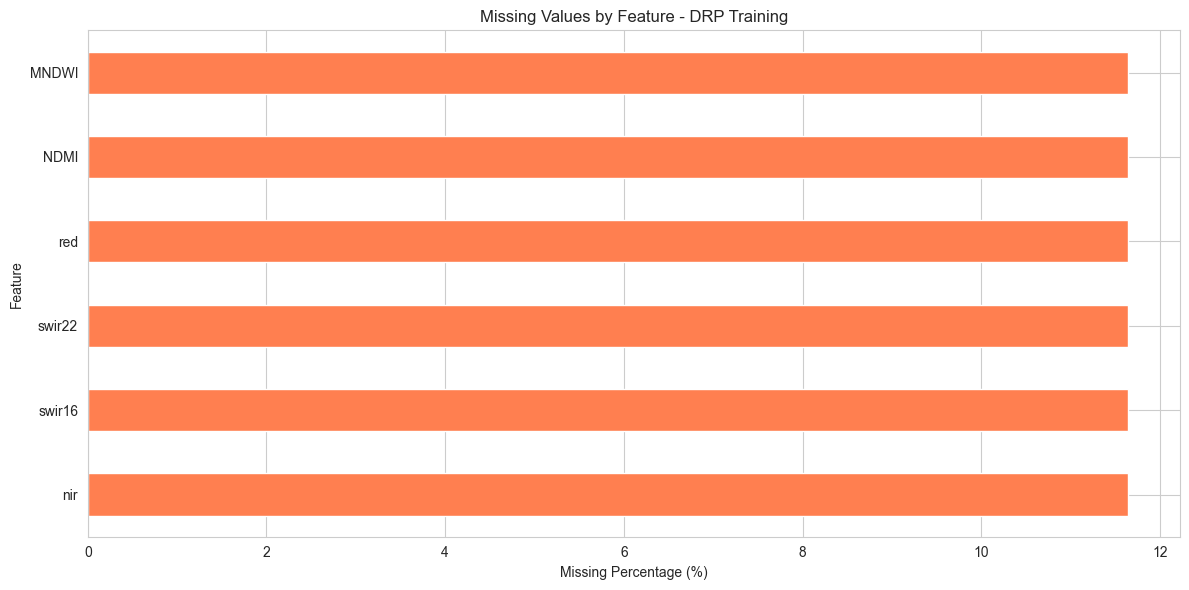


Dataset: DRP Validation
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :   9.50% (19 rows)
swir16                                  :   9.50% (19 rows)
swir22                                  :   9.50% (19 rows)
red                                     :   9.50% (19 rows)
NDMI                                    :   9.50% (19 rows)
MNDWI                                   :   9.50% (19 rows)


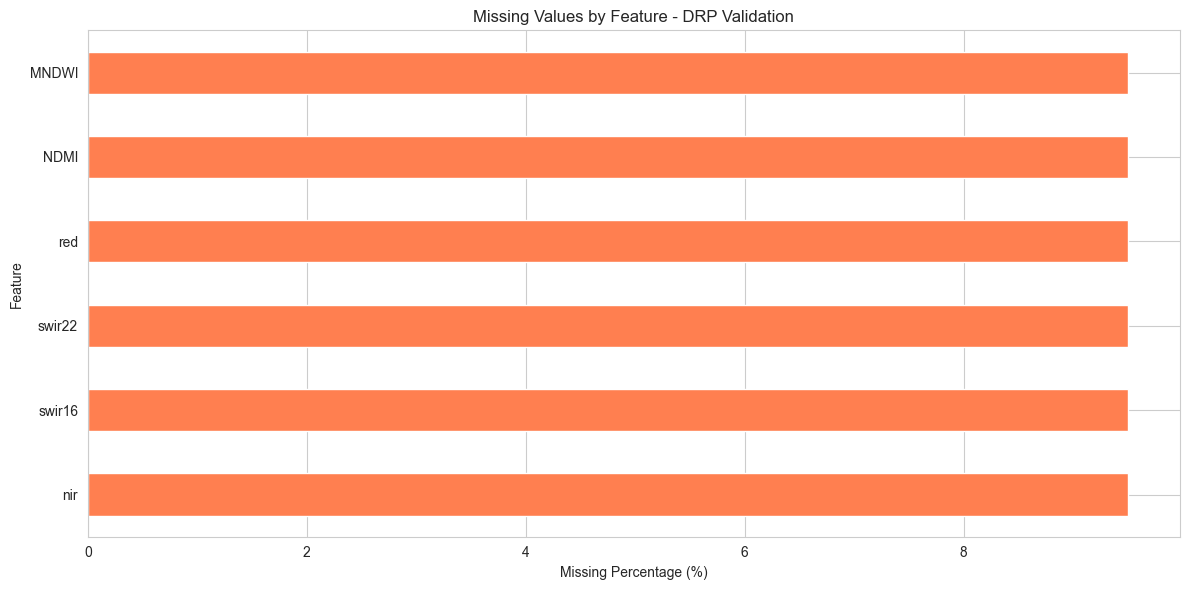


Dataset: EC Training
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :  11.64% (1,085 rows)
swir16                                  :  11.64% (1,085 rows)
swir22                                  :  11.64% (1,085 rows)
red                                     :  11.64% (1,085 rows)
NDMI                                    :  11.64% (1,085 rows)
MNDWI                                   :  11.64% (1,085 rows)


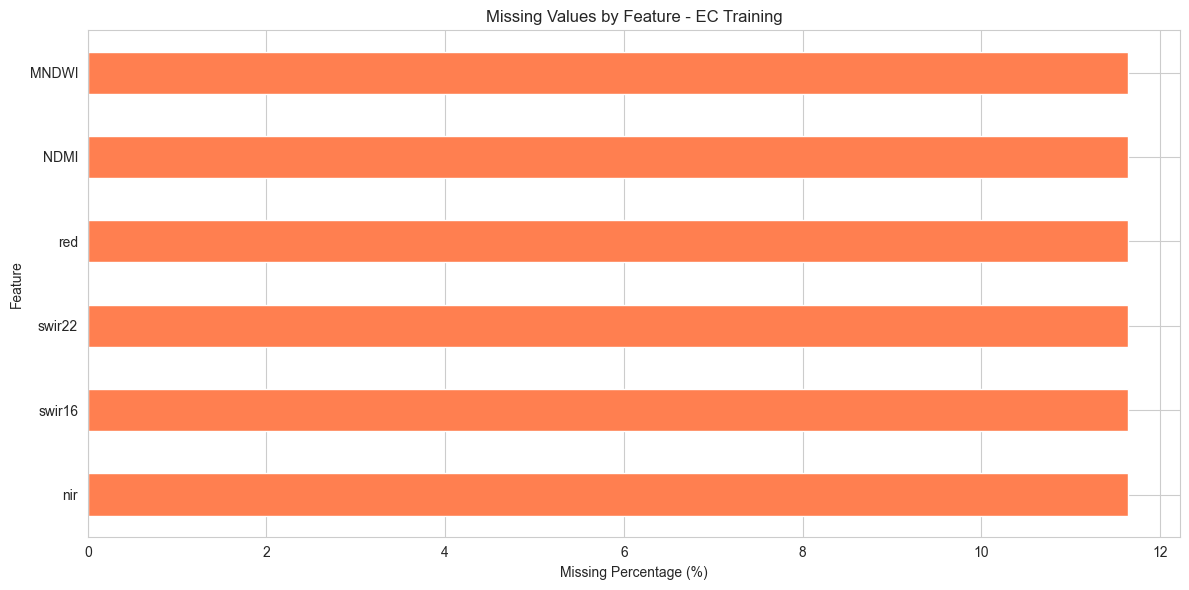


Dataset: EC Validation
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :   9.50% (19 rows)
swir16                                  :   9.50% (19 rows)
swir22                                  :   9.50% (19 rows)
red                                     :   9.50% (19 rows)
NDMI                                    :   9.50% (19 rows)
MNDWI                                   :   9.50% (19 rows)


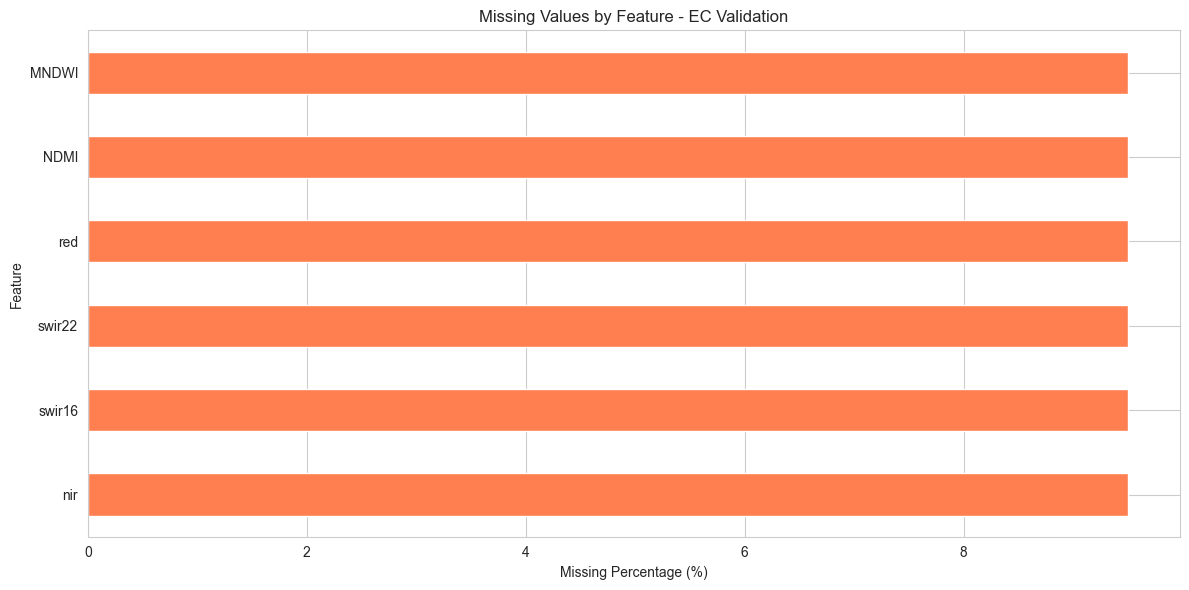


Dataset: TA Training
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :  11.64% (1,085 rows)
swir16                                  :  11.64% (1,085 rows)
swir22                                  :  11.64% (1,085 rows)
red                                     :  11.64% (1,085 rows)
NDMI                                    :  11.64% (1,085 rows)
MNDWI                                   :  11.64% (1,085 rows)


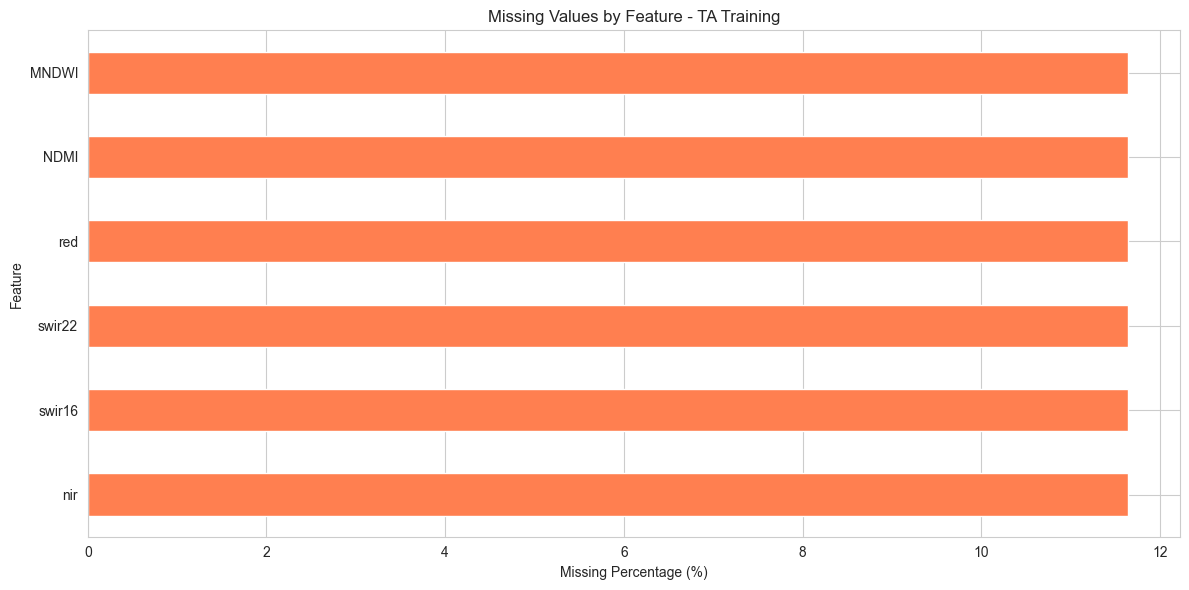


Dataset: TA Validation
Total features: 25
Features with missing values: 6
Features without missing values: 19

Missing Value Percentages:
------------------------------------------------------------
nir                                     :   9.50% (19 rows)
swir16                                  :   9.50% (19 rows)
swir22                                  :   9.50% (19 rows)
red                                     :   9.50% (19 rows)
NDMI                                    :   9.50% (19 rows)
MNDWI                                   :   9.50% (19 rows)


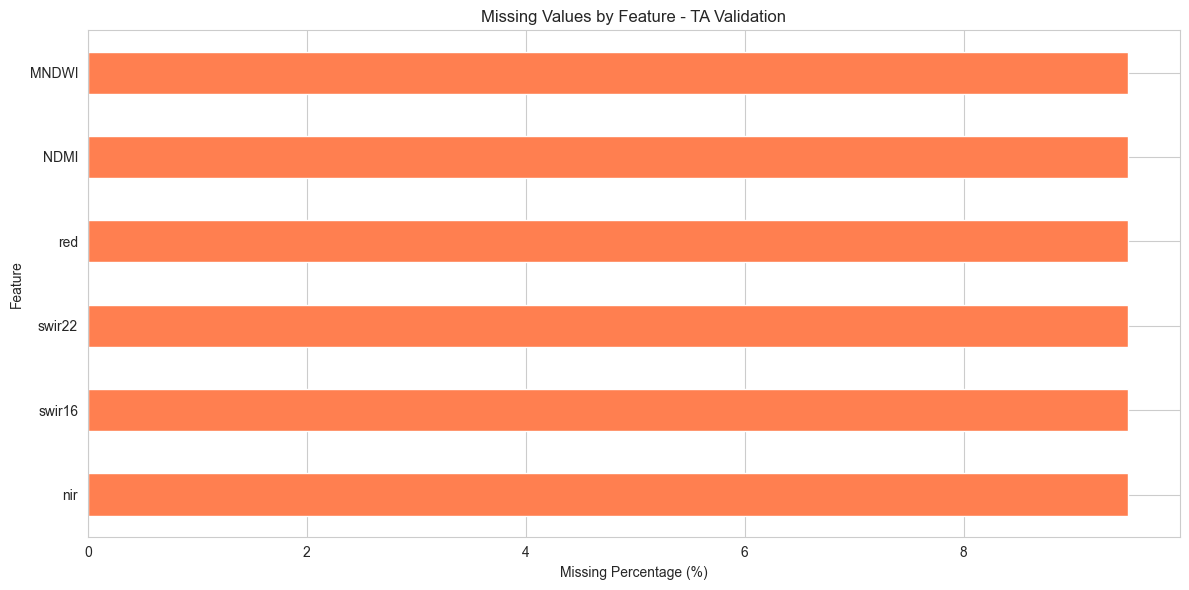

In [8]:
def analyze_missing_per_feature(df, dataset_name):
    """
    Analyze and visualize missing values per feature
    """
    # Calculate missing percentages
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    
    # Filter features with missing values
    missing_features = missing_pct[missing_pct > 0]
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total features: {len(df.columns)}")
    print(f"Features with missing values: {len(missing_features)}")
    print(f"Features without missing values: {len(df.columns) - len(missing_features)}")
    
    if len(missing_features) > 0:
        print(f"\nMissing Value Percentages:")
        print("-" * 60)
        for feature, pct in missing_features.items():
            count = df[feature].isnull().sum()
            print(f"{feature:40s}: {pct:6.2f}% ({count:,} rows)")
        
        # Visualize
        plt.figure(figsize=(12, max(6, len(missing_features) * 0.4)))
        missing_features.plot(kind='barh', color='coral')
        plt.xlabel('Missing Percentage (%)')
        plt.ylabel('Feature')
        plt.title(f'Missing Values by Feature - {dataset_name}')
        plt.tight_layout()
        plt.show()
    else:
        print("\n✓ No missing values in any features!")
    
    return missing_pct

# Analyze each dataset
missing_summaries = {}
for name, df in datasets.items():
    missing_summaries[name] = analyze_missing_per_feature(df, name)

## 2. Percentage of Missing Values Per Row


Dataset: DRP Training

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 9,319
Rows with no missing values: 8,234 (88.36%)
Rows with missing values: 1,085 (11.64%)

Missing percentage per row:
  Mean: 2.79%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.70%


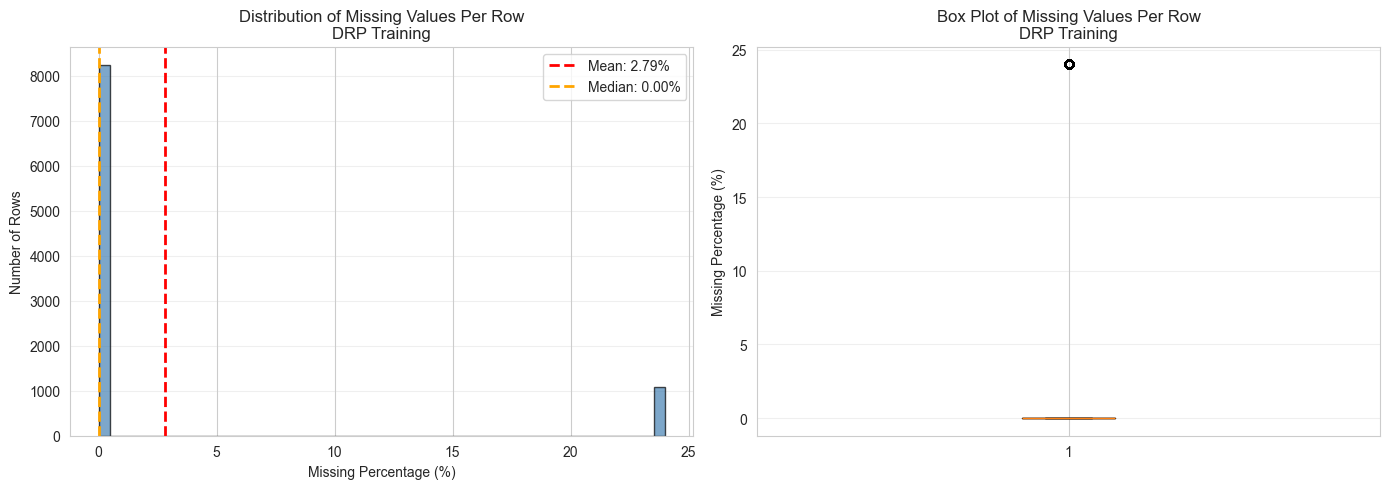


Dataset: DRP Validation

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 200
Rows with no missing values: 181 (90.50%)
Rows with missing values: 19 (9.50%)

Missing percentage per row:
  Mean: 2.28%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.05%


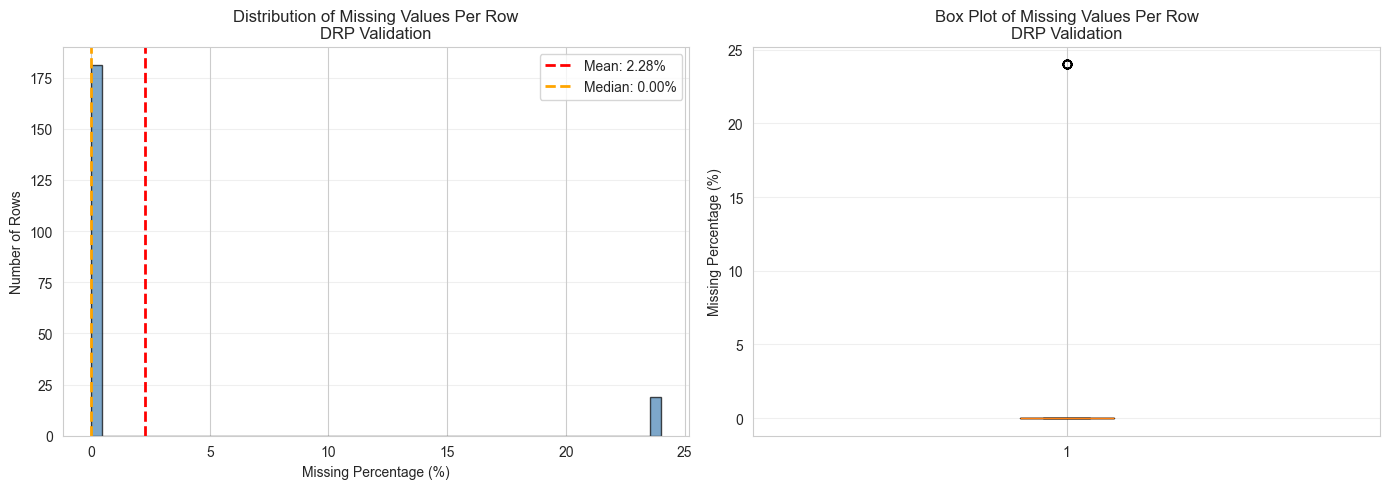


Dataset: EC Training

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 9,319
Rows with no missing values: 8,234 (88.36%)
Rows with missing values: 1,085 (11.64%)

Missing percentage per row:
  Mean: 2.79%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.70%


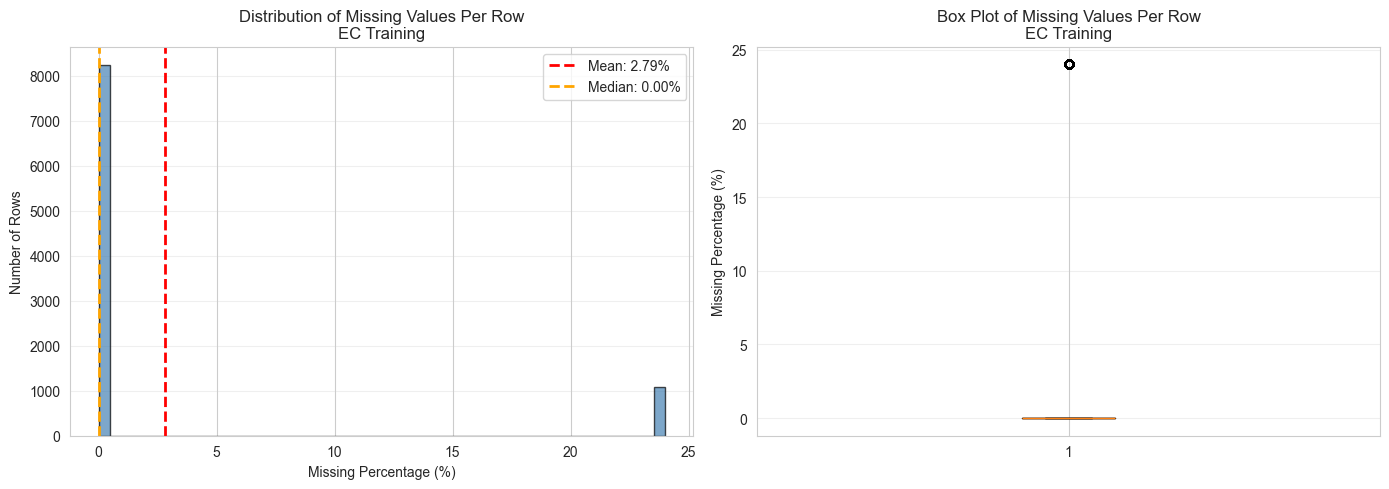


Dataset: EC Validation

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 200
Rows with no missing values: 181 (90.50%)
Rows with missing values: 19 (9.50%)

Missing percentage per row:
  Mean: 2.28%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.05%


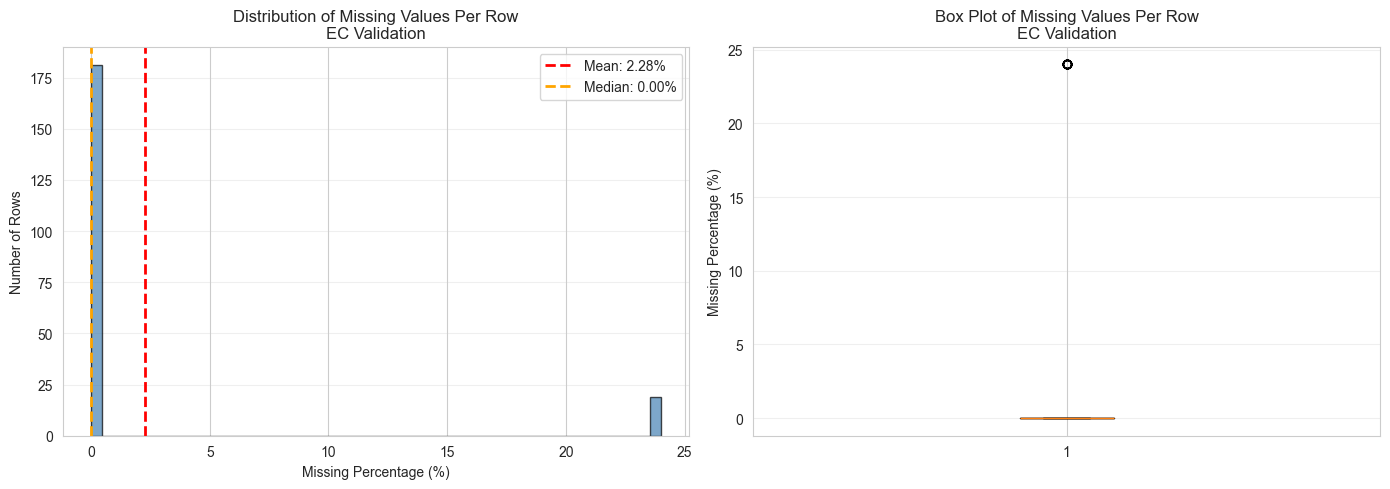


Dataset: TA Training

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 9,319
Rows with no missing values: 8,234 (88.36%)
Rows with missing values: 1,085 (11.64%)

Missing percentage per row:
  Mean: 2.79%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.70%


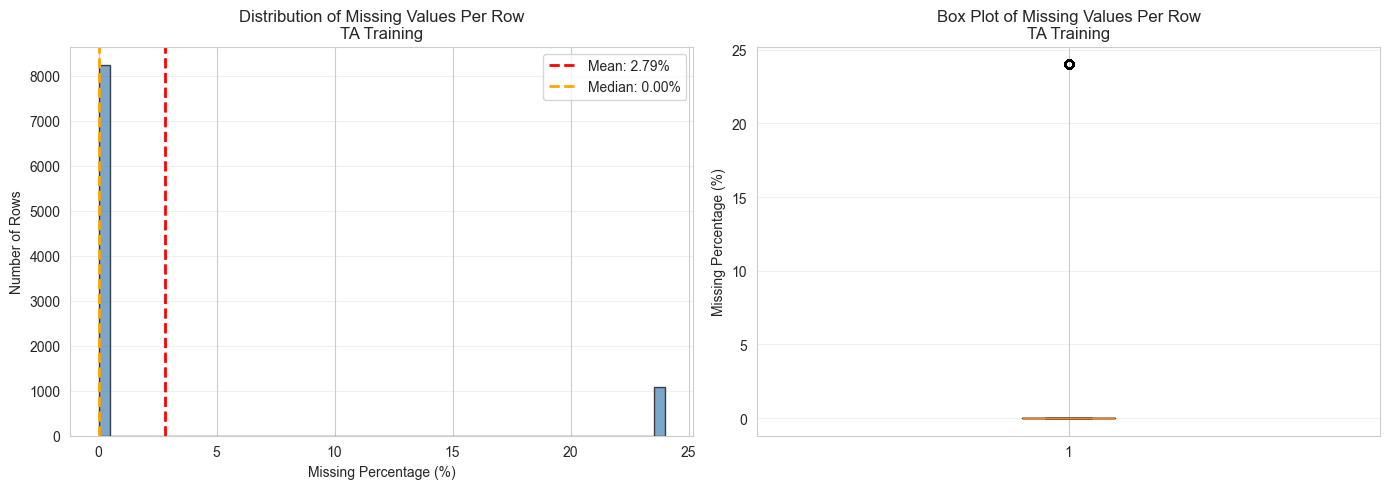


Dataset: TA Validation

Row Missingness Statistics:
------------------------------------------------------------
Total rows: 200
Rows with no missing values: 181 (90.50%)
Rows with missing values: 19 (9.50%)

Missing percentage per row:
  Mean: 2.28%
  Median: 0.00%
  Min: 0.00%
  Max: 24.00%
  Std: 7.05%


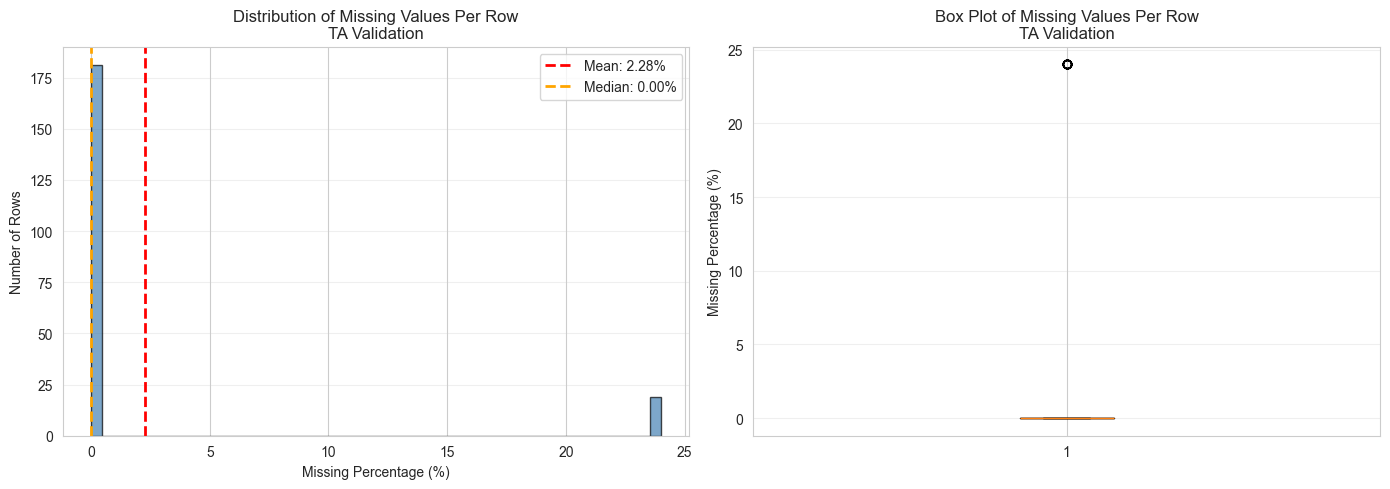

In [9]:
def analyze_missing_per_row(df, dataset_name):
    """
    Analyze and visualize missing values per row
    """
    # Calculate missing percentages per row
    missing_per_row = (df.isnull().sum(axis=1) / len(df.columns) * 100)
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"\nRow Missingness Statistics:")
    print("-" * 60)
    print(f"Total rows: {len(df):,}")
    print(f"Rows with no missing values: {(missing_per_row == 0).sum():,} ({(missing_per_row == 0).sum()/len(df)*100:.2f}%)")
    print(f"Rows with missing values: {(missing_per_row > 0).sum():,} ({(missing_per_row > 0).sum()/len(df)*100:.2f}%)")
    print(f"\nMissing percentage per row:")
    print(f"  Mean: {missing_per_row.mean():.2f}%")
    print(f"  Median: {missing_per_row.median():.2f}%")
    print(f"  Min: {missing_per_row.min():.2f}%")
    print(f"  Max: {missing_per_row.max():.2f}%")
    print(f"  Std: {missing_per_row.std():.2f}%")
    
    # Distribution of missing percentages
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(missing_per_row, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(missing_per_row.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {missing_per_row.mean():.2f}%')
    axes[0].axvline(missing_per_row.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {missing_per_row.median():.2f}%')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_ylabel('Number of Rows')
    axes[0].set_title(f'Distribution of Missing Values Per Row\n{dataset_name}')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(missing_per_row, vert=True)
    axes[1].set_ylabel('Missing Percentage (%)')
    axes[1].set_title(f'Box Plot of Missing Values Per Row\n{dataset_name}')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return missing_per_row

# Analyze each dataset
row_missing_summaries = {}
for name, df in datasets.items():
    row_missing_summaries[name] = analyze_missing_per_row(df, name)

## 3. Missingness Correlations (Null Patterns)


Dataset: DRP Training

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


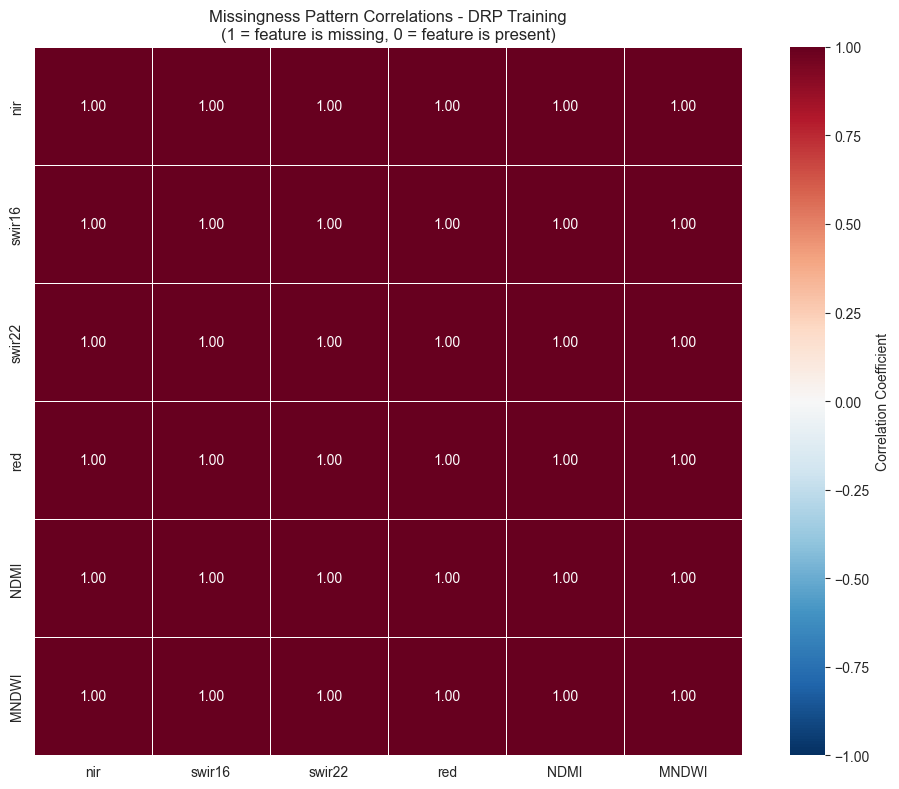


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


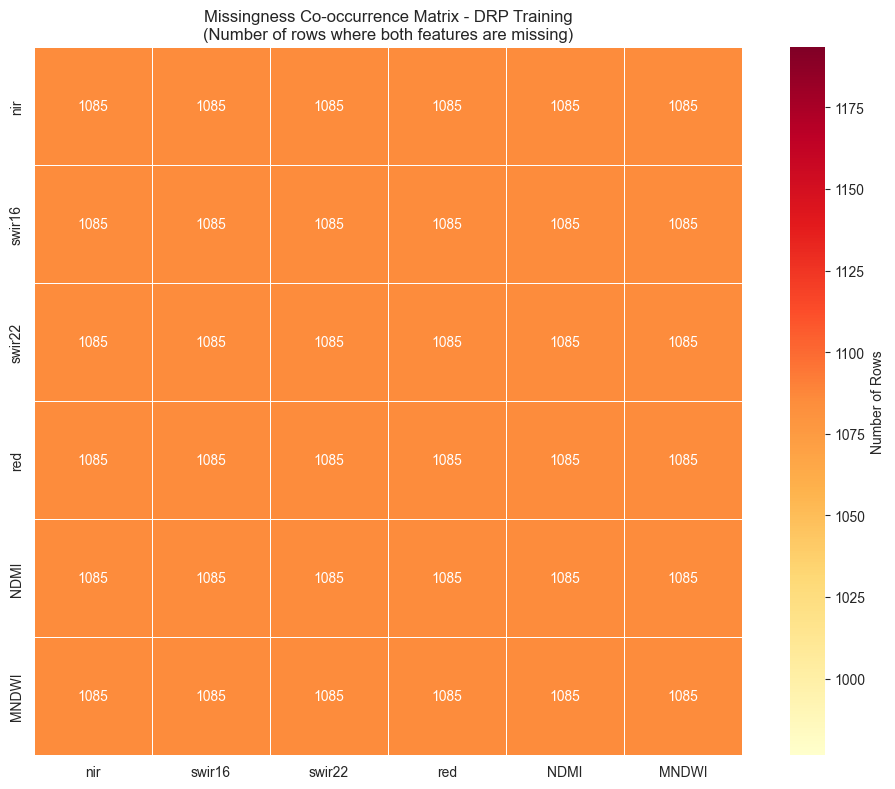


Dataset: DRP Validation

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


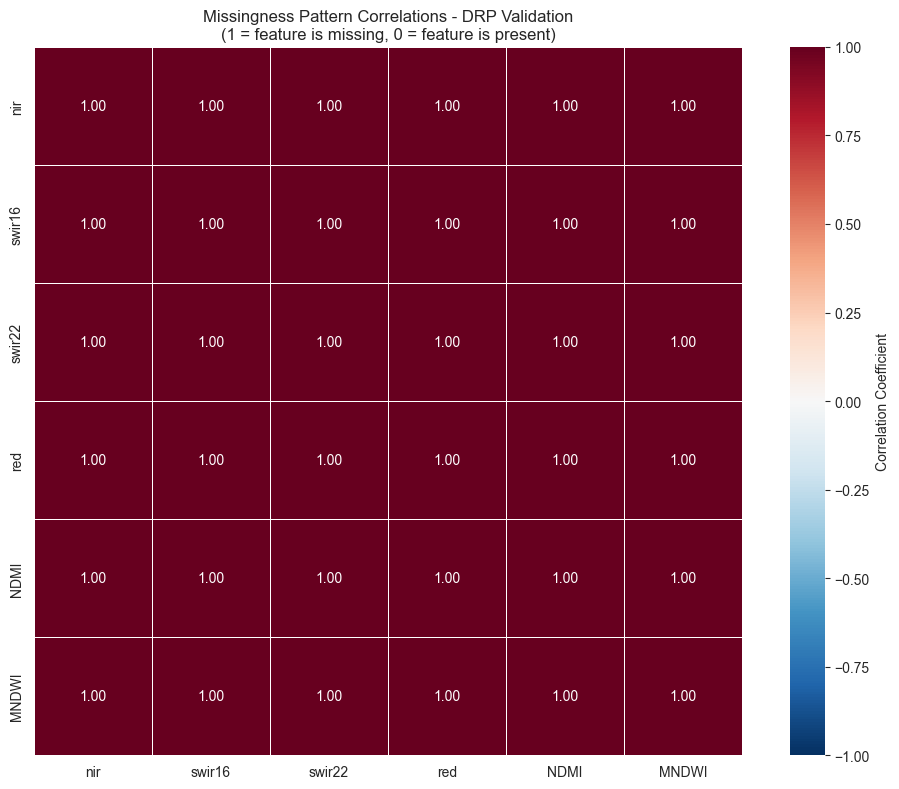


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


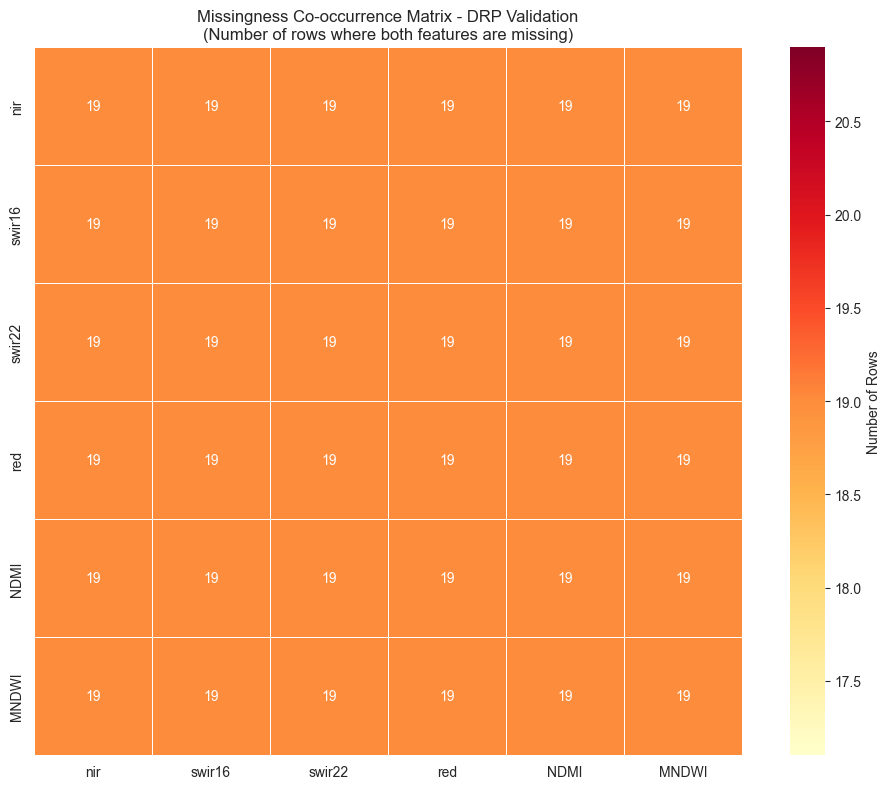


Dataset: EC Training

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


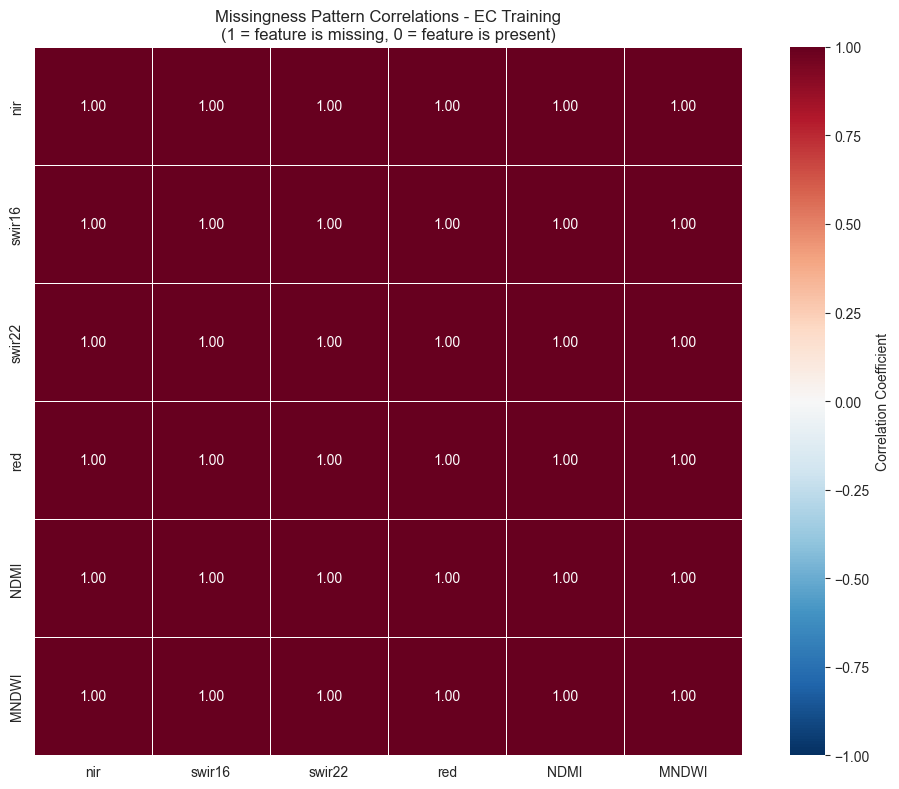


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


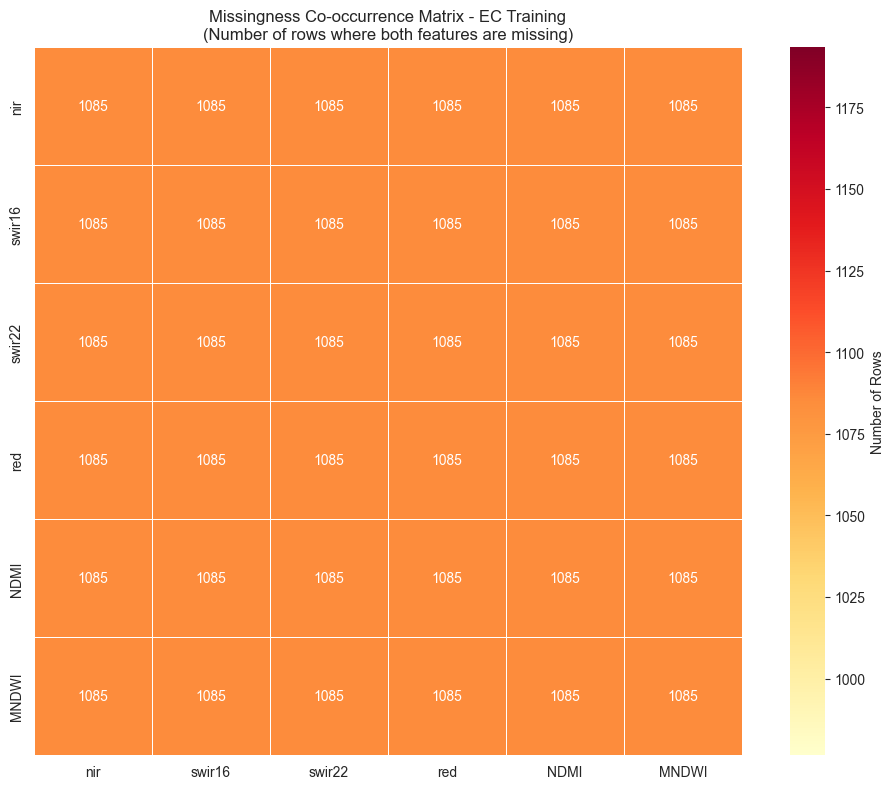


Dataset: EC Validation

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


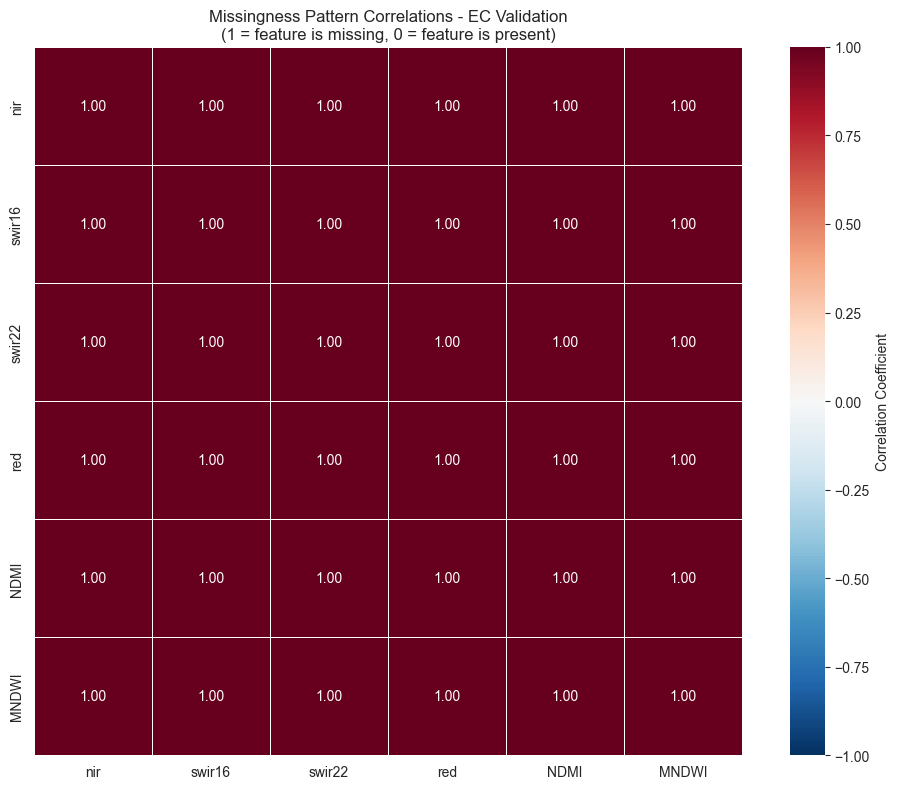


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


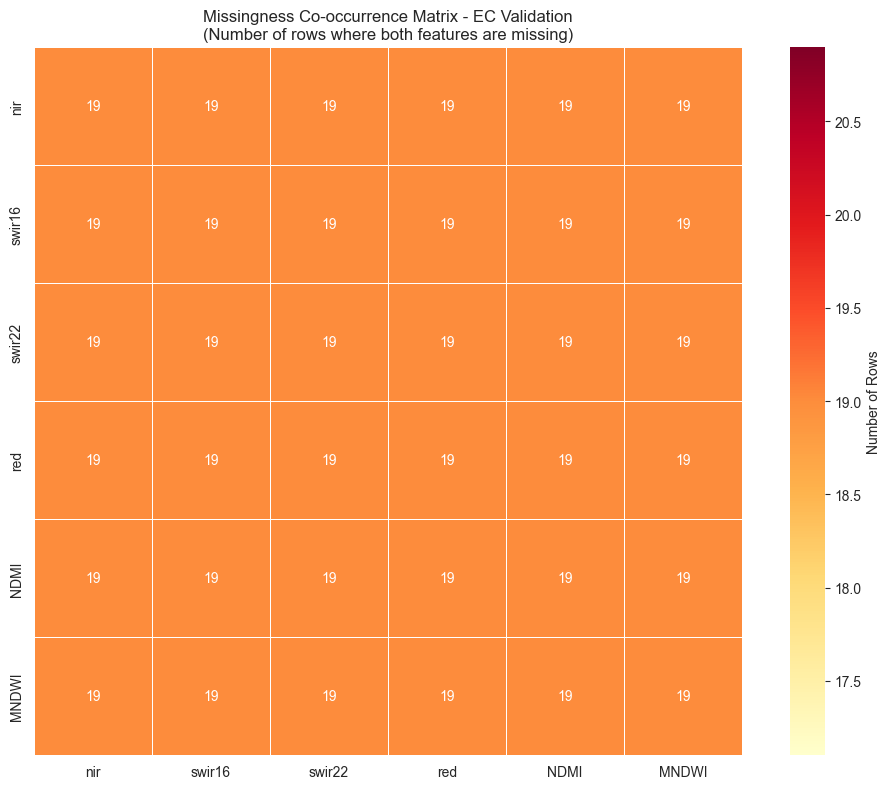


Dataset: TA Training

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


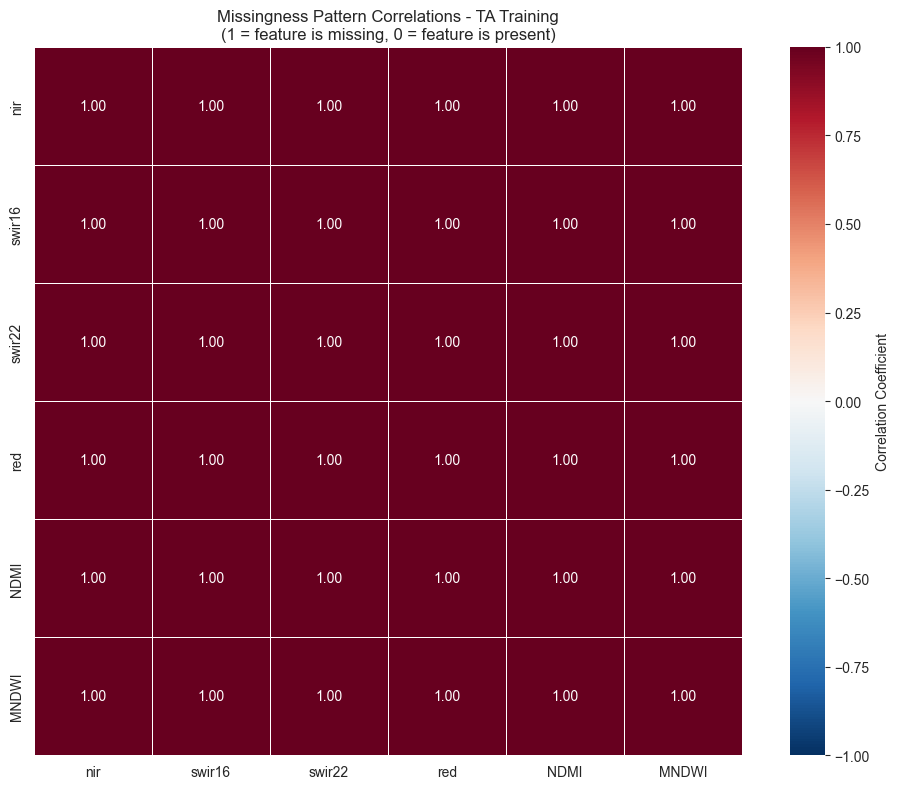


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


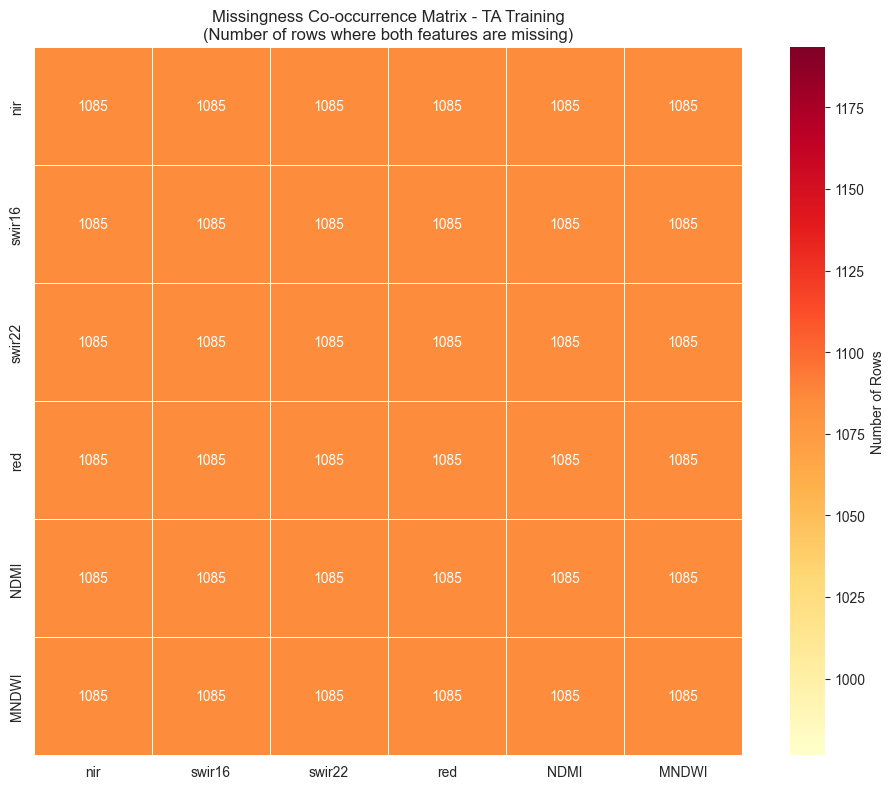


Dataset: TA Validation

Analyzing missingness correlations for 6 features with missing values

Strong Missingness Correlations (|r| >= 0.3):
--------------------------------------------------------------------------------
nir <-> swir16: r = 1.0000
nir <-> swir22: r = 1.0000
nir <-> red: r = 1.0000
nir <-> NDMI: r = 1.0000
nir <-> MNDWI: r = 1.0000
swir16 <-> swir22: r = 1.0000
swir16 <-> red: r = 1.0000
swir16 <-> NDMI: r = 1.0000
swir16 <-> MNDWI: r = 1.0000
swir22 <-> red: r = 1.0000
swir22 <-> NDMI: r = 1.0000
swir22 <-> MNDWI: r = 1.0000
red <-> NDMI: r = 1.0000
red <-> MNDWI: r = 1.0000
NDMI <-> MNDWI: r = 1.0000


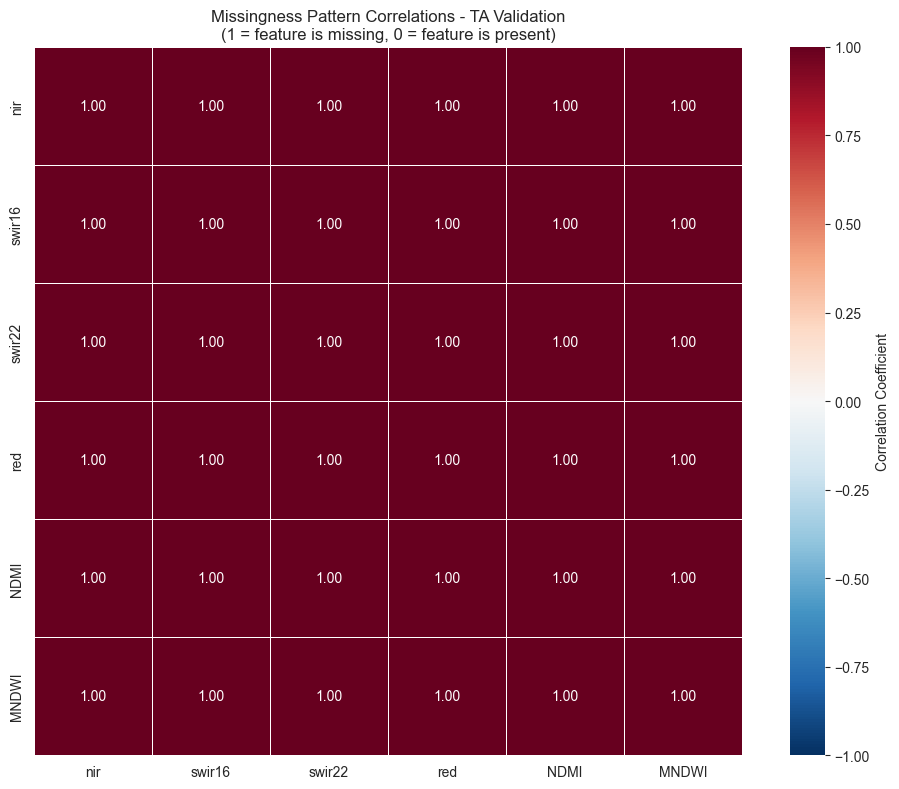


Co-occurrence Analysis (number of rows where both features are missing):
--------------------------------------------------------------------------------


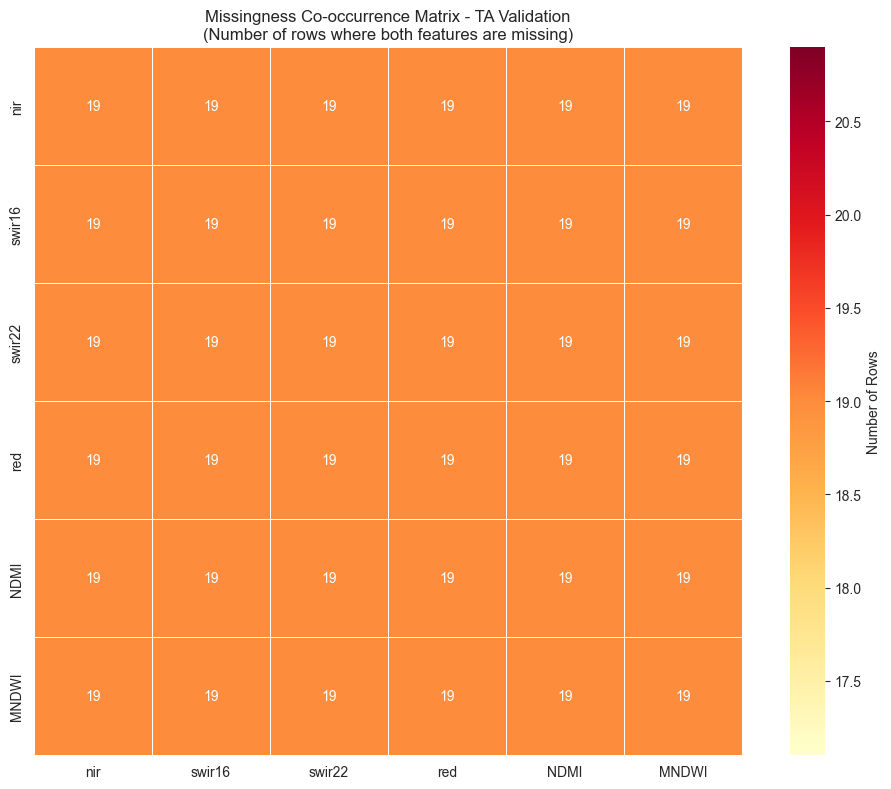

In [10]:
def analyze_missingness_correlations(df, dataset_name, threshold=0.1):
    """
    Analyze correlations between missing value patterns
    """
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    
    # Create binary matrix of missingness (1 = missing, 0 = not missing)
    missing_matrix = df.isnull().astype(int)
    
    # Get columns with any missing values
    cols_with_missing = missing_matrix.columns[missing_matrix.sum() > 0].tolist()
    
    if len(cols_with_missing) == 0:
        print("\n✓ No missing values in dataset - no correlation analysis needed!")
        return None
    
    print(f"\nAnalyzing missingness correlations for {len(cols_with_missing)} features with missing values")
    
    # Calculate correlation matrix for missingness patterns
    missing_corr = missing_matrix[cols_with_missing].corr()
    
    # Find strong correlations (excluding diagonal)
    strong_correlations = []
    for i in range(len(missing_corr.columns)):
        for j in range(i+1, len(missing_corr.columns)):
            corr_value = missing_corr.iloc[i, j]
            if abs(corr_value) >= threshold:
                strong_correlations.append((
                    missing_corr.columns[i],
                    missing_corr.columns[j],
                    corr_value
                ))
    
    if strong_correlations:
        print(f"\nStrong Missingness Correlations (|r| >= {threshold}):")
        print("-" * 80)
        strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
        for feat1, feat2, corr in strong_correlations:
            print(f"{feat1} <-> {feat2}: r = {corr:.4f}")
    else:
        print(f"\nNo strong missingness correlations found (threshold: {threshold})")
    
    # Visualize correlation matrix
    if len(cols_with_missing) > 1:
        plt.figure(figsize=(max(10, len(cols_with_missing) * 0.6), max(8, len(cols_with_missing) * 0.5)))
        sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    vmin=-1, vmax=1, square=True, linewidths=0.5,
                    cbar_kws={'label': 'Correlation Coefficient'})
        plt.title(f'Missingness Pattern Correlations - {dataset_name}\n(1 = feature is missing, 0 = feature is present)')
        plt.tight_layout()
        plt.show()
        
        # Co-occurrence matrix (how often features are missing together)
        print("\nCo-occurrence Analysis (number of rows where both features are missing):")
        print("-" * 80)
        co_occurrence = missing_matrix[cols_with_missing].T @ missing_matrix[cols_with_missing]
        
        plt.figure(figsize=(max(10, len(cols_with_missing) * 0.6), max(8, len(cols_with_missing) * 0.5)))
        sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
                    square=True, linewidths=0.5,
                    cbar_kws={'label': 'Number of Rows'})
        plt.title(f'Missingness Co-occurrence Matrix - {dataset_name}\n(Number of rows where both features are missing)')
        plt.tight_layout()
        plt.show()
    
    return missing_corr, strong_correlations

# Analyze each dataset
correlation_summaries = {}
for name, df in datasets.items():
    correlation_summaries[name] = analyze_missingness_correlations(df, name, threshold=0.3)

## 6. Model-Based Multivariate Imputation

We'll use **IterativeImputer** (MICE - Multivariate Imputation by Chained Equations) to fill missing values. This method:
- Models each feature with missing values as a function of other features
- Uses an iterative round-robin approach to impute missing values
- Captures complex relationships between features
- More sophisticated than simple mean/median imputation

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

def impute_dataset(df, dataset_name, random_state=42):
    """
    Impute missing values using IterativeImputer with RandomForest
    """
    print(f"\n{'='*80}")
    print(f"Imputing: {dataset_name}")
    print(f"{'='*80}")
    
    # Separate metadata columns that shouldn't be imputed
    metadata_cols = ['latitude', 'longitude', 'sample_date']
    
    # Get feature columns (exclude metadata)
    feature_cols = [col for col in df.columns if col not in metadata_cols]
    
    # Check if there are any missing values
    total_missing = df[feature_cols].isnull().sum().sum()
    
    if total_missing == 0:
        print("✓ No missing values found - no imputation needed!")
        return df.copy()
    
    print(f"\nBefore imputation:")
    print(f"  Total missing values: {total_missing:,}")
    print(f"  Missing percentage: {(total_missing / (len(df) * len(feature_cols))) * 100:.2f}%")
    
    # Features with missing values
    features_with_missing = df[feature_cols].columns[df[feature_cols].isnull().any()].tolist()
    print(f"  Features with missing values: {len(features_with_missing)}")
    for feat in features_with_missing:
        missing_count = df[feat].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        print(f"    - {feat}: {missing_count} ({missing_pct:.2f}%)")
    
    # Create a copy for imputation
    df_imputed = df.copy()
    
    # Initialize IterativeImputer with RandomForest estimator
    # RandomForest is robust and can capture non-linear relationships
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=10, random_state=random_state, n_jobs=-1),
        max_iter=10,
        random_state=random_state,
        verbose=0
    )
    
    print("\n⏳ Performing iterative imputation with RandomForest...")
    
    # Impute only the feature columns
    df_imputed[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    print("✓ Imputation complete!")
    
    # Verify no missing values remain
    remaining_missing = df_imputed[feature_cols].isnull().sum().sum()
    print(f"\nAfter imputation:")
    print(f"  Remaining missing values: {remaining_missing}")
    
    if remaining_missing == 0:
        print("  ✓ All missing values successfully imputed!")
    else:
        print(f"  ⚠ Warning: {remaining_missing} missing values still remain")
    
    return df_imputed

# Impute all datasets
imputed_datasets = {}
for name, df in datasets.items():
    imputed_datasets[name] = impute_dataset(df, name)

print("\n" + "="*80)
print("ALL DATASETS IMPUTED SUCCESSFULLY")
print("="*80)


Imputing: DRP Training

Before imputation:
  Total missing values: 6,510
  Missing percentage: 3.18%
  Features with missing values: 6
    - nir: 1085 (11.64%)
    - swir16: 1085 (11.64%)
    - swir22: 1085 (11.64%)
    - red: 1085 (11.64%)
    - NDMI: 1085 (11.64%)
    - MNDWI: 1085 (11.64%)

⏳ Performing iterative imputation with RandomForest...
✓ Imputation complete!

After imputation:
  Remaining missing values: 0
  ✓ All missing values successfully imputed!

Imputing: DRP Validation

Before imputation:
  Total missing values: 114
  Missing percentage: 2.59%
  Features with missing values: 6
    - nir: 19 (9.50%)
    - swir16: 19 (9.50%)
    - swir22: 19 (9.50%)
    - red: 19 (9.50%)
    - NDMI: 19 (9.50%)
    - MNDWI: 19 (9.50%)

⏳ Performing iterative imputation with RandomForest...
✓ Imputation complete!

After imputation:
  Remaining missing values: 0
  ✓ All missing values successfully imputed!

Imputing: EC Training

Before imputation:
  Total missing values: 6,510
  Missing

## 7. Validation of Imputed Values

Let's compare the distributions of imputed values vs. original values to ensure the imputation is reasonable.


Validation: DRP Training

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14045.4854, Std: 2953.2236
    Min: 3992.0000, Max: 65535.0000
  Imputed values statistics:
    Mean: 14177.3816, Std: 215.4436
    Min: 13557.5000, Max: 14961.9500
  After imputation (all values):
    Mean: 14060.8419, Std: 2777.2600

swir16:
  Original (non-missing) statistics:
    Mean: 13567.4593, Std: 3348.5177
    Min: 3672.5000, Max: 65535.0000
  Imputed values statistics:
    Mean: 13735.8478, Std: 290.6577
    Min: 12544.5500, Max: 15218.5500
  After imputation (all values):
    Mean: 13587.0646, Std: 3149.5571

swir22:
  Original (non-missing) statistics:
    Mean: 11425.5384, Std: 2548.1935
    Min: 3634.0000, Max: 31202.5000
  Imputed values statistics:
    Mean: 11514.1047, Std: 247.0174
    Min: 10543.6000, Max: 13116.4000
  After imputation (all values):
    Mean: 11435.8500, Std: 2396.8956

red:
  Original (non-missing) statistics:
    Mean: 10

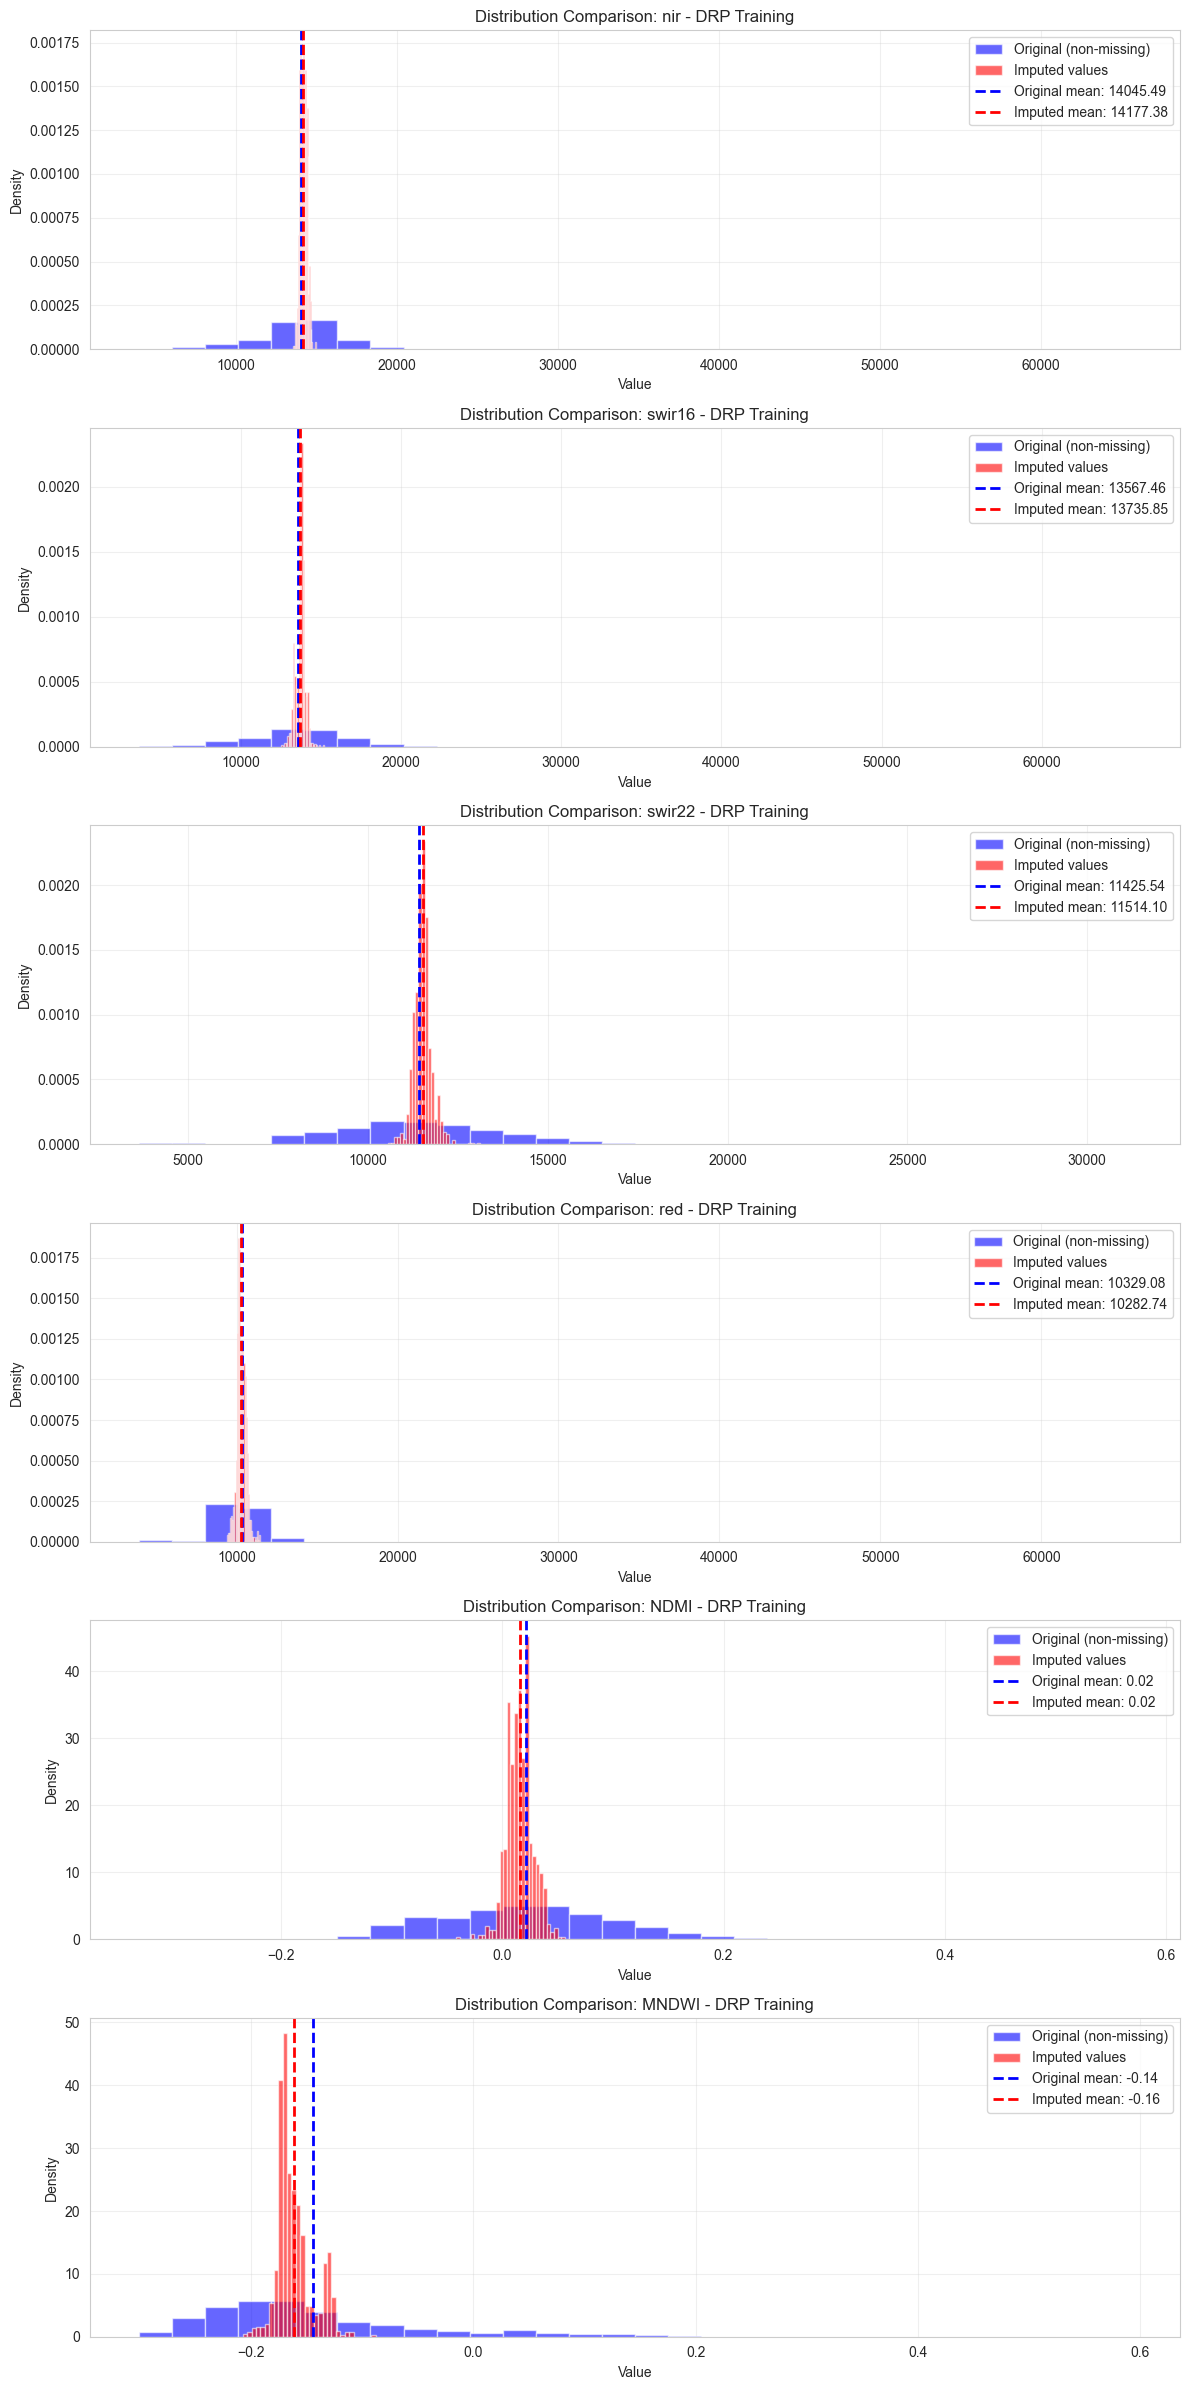


Validation: DRP Validation

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14462.9558, Std: 2292.4889
    Min: 6281.0000, Max: 21308.0000
  Imputed values statistics:
    Mean: 15802.5289, Std: 977.6329
    Min: 13239.2500, Max: 17299.0500
  After imputation (all values):
    Mean: 14590.2152, Std: 2235.0007

swir16:
  Original (non-missing) statistics:
    Mean: 12332.0110, Std: 2031.5636
    Min: 5173.5000, Max: 18512.5000
  Imputed values statistics:
    Mean: 12506.7421, Std: 288.7278
    Min: 11824.4000, Max: 12970.6000
  After imputation (all values):
    Mean: 12348.6105, Std: 1934.7791

swir22:
  Original (non-missing) statistics:
    Mean: 10297.0884, Std: 1702.4975
    Min: 4286.5000, Max: 16452.0000
  Imputed values statistics:
    Mean: 10045.3632, Std: 227.6377
    Min: 9585.1000, Max: 10481.3500
  After imputation (all values):
    Mean: 10273.1745, Std: 1622.3190

red:
  Original (non-missing) statistics:
    Mean: 9

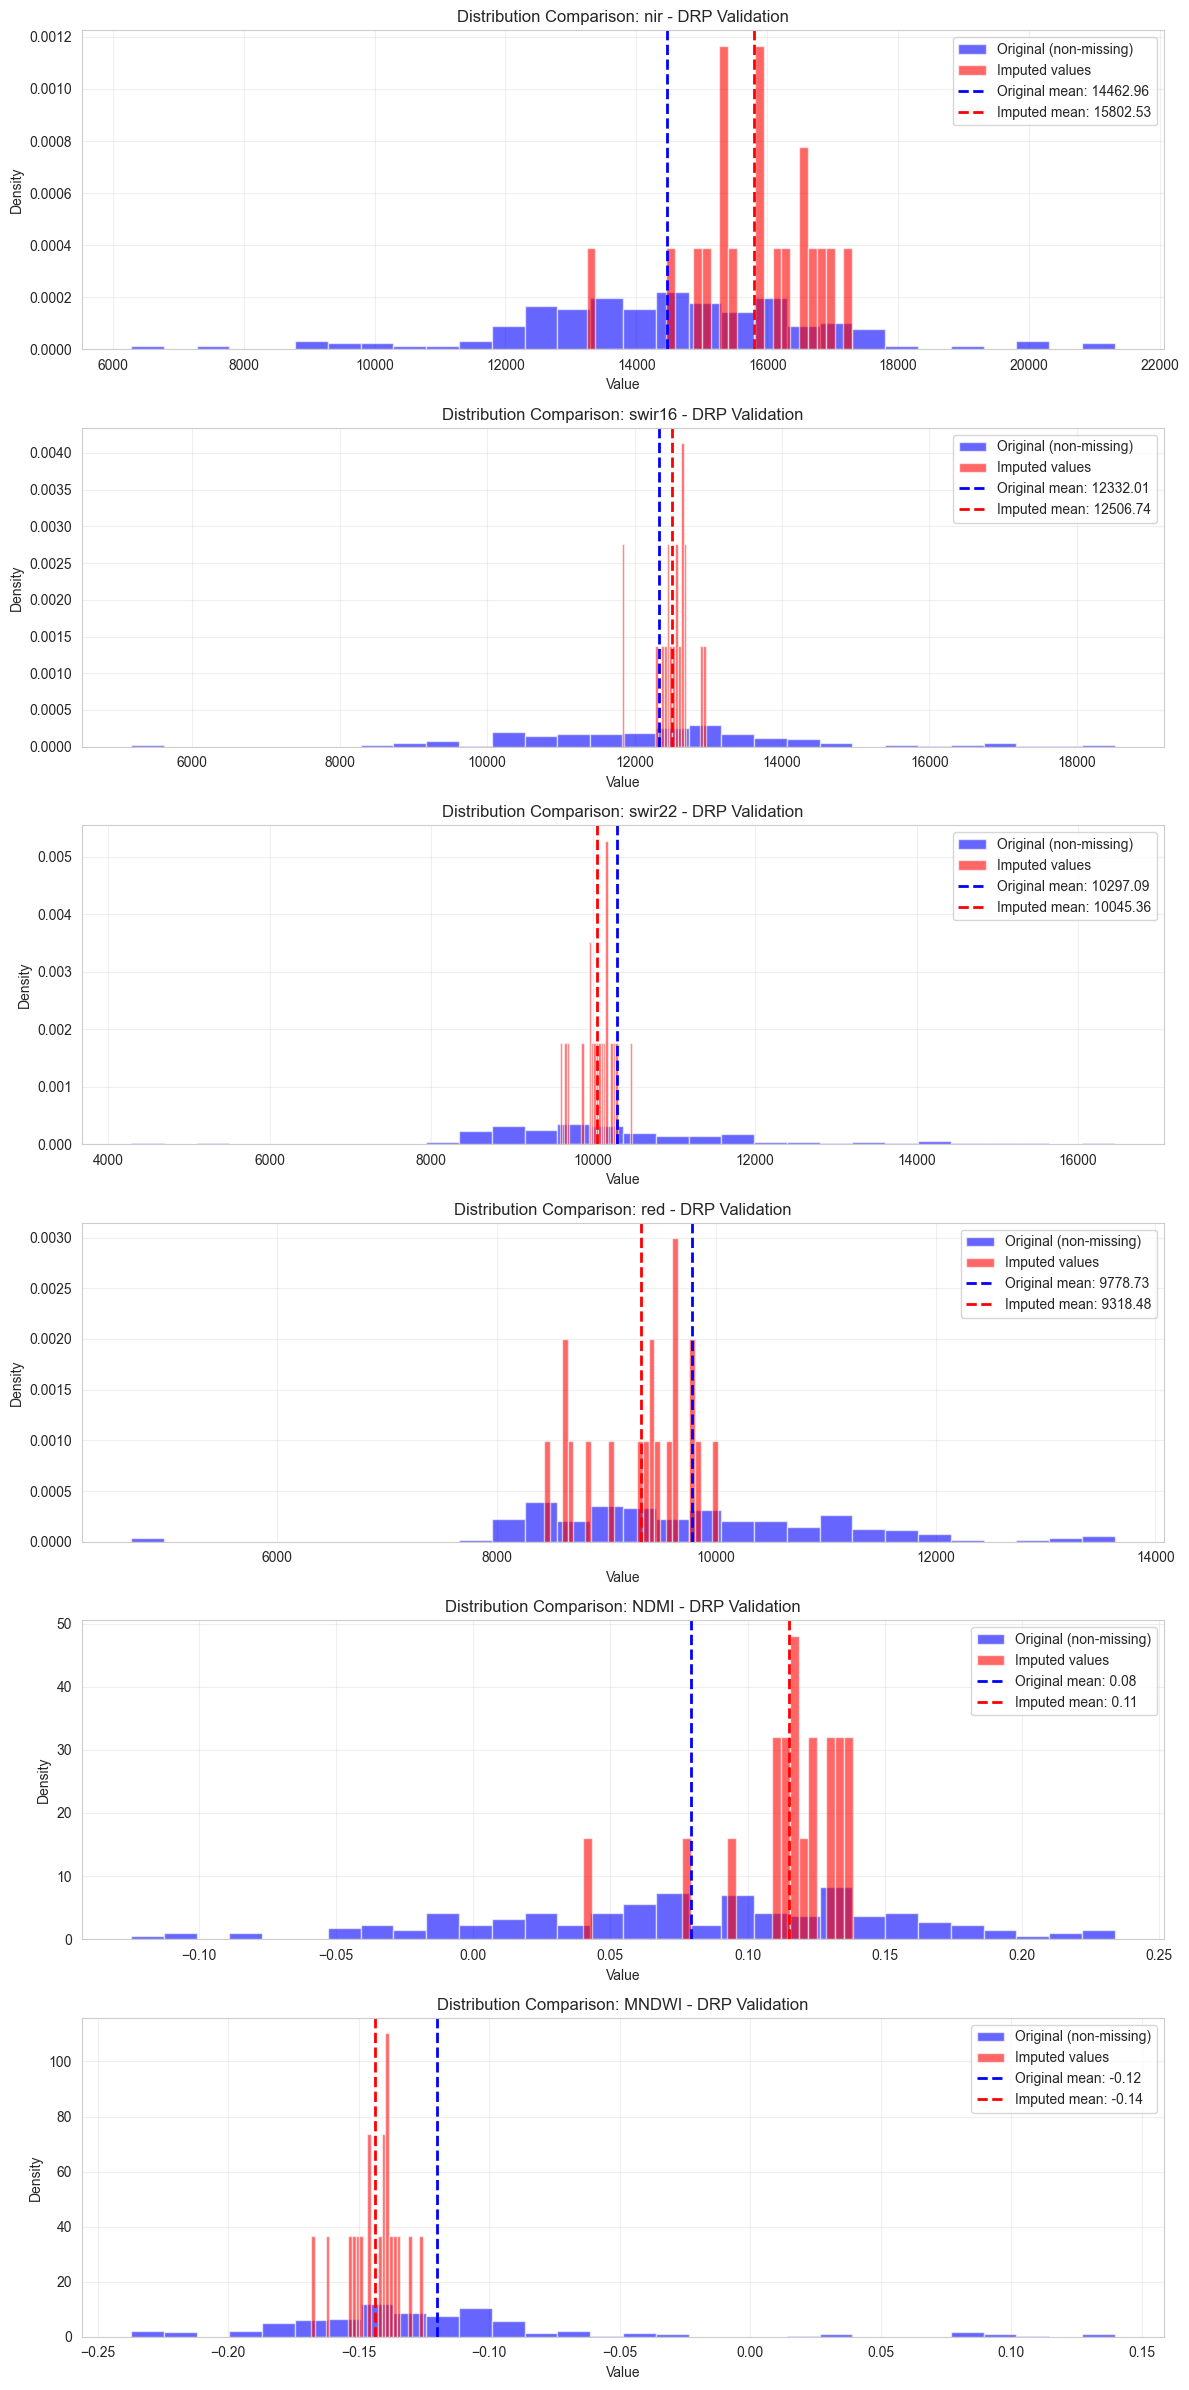


Validation: EC Training

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14045.4854, Std: 2953.2236
    Min: 3992.0000, Max: 65535.0000
  Imputed values statistics:
    Mean: 14177.3816, Std: 215.4436
    Min: 13557.5000, Max: 14961.9500
  After imputation (all values):
    Mean: 14060.8419, Std: 2777.2600

swir16:
  Original (non-missing) statistics:
    Mean: 13567.4593, Std: 3348.5177
    Min: 3672.5000, Max: 65535.0000
  Imputed values statistics:
    Mean: 13735.8478, Std: 290.6577
    Min: 12544.5500, Max: 15218.5500
  After imputation (all values):
    Mean: 13587.0646, Std: 3149.5571

swir22:
  Original (non-missing) statistics:
    Mean: 11425.5384, Std: 2548.1935
    Min: 3634.0000, Max: 31202.5000
  Imputed values statistics:
    Mean: 11514.1047, Std: 247.0174
    Min: 10543.6000, Max: 13116.4000
  After imputation (all values):
    Mean: 11435.8500, Std: 2396.8956

red:
  Original (non-missing) statistics:
    Mean: 103

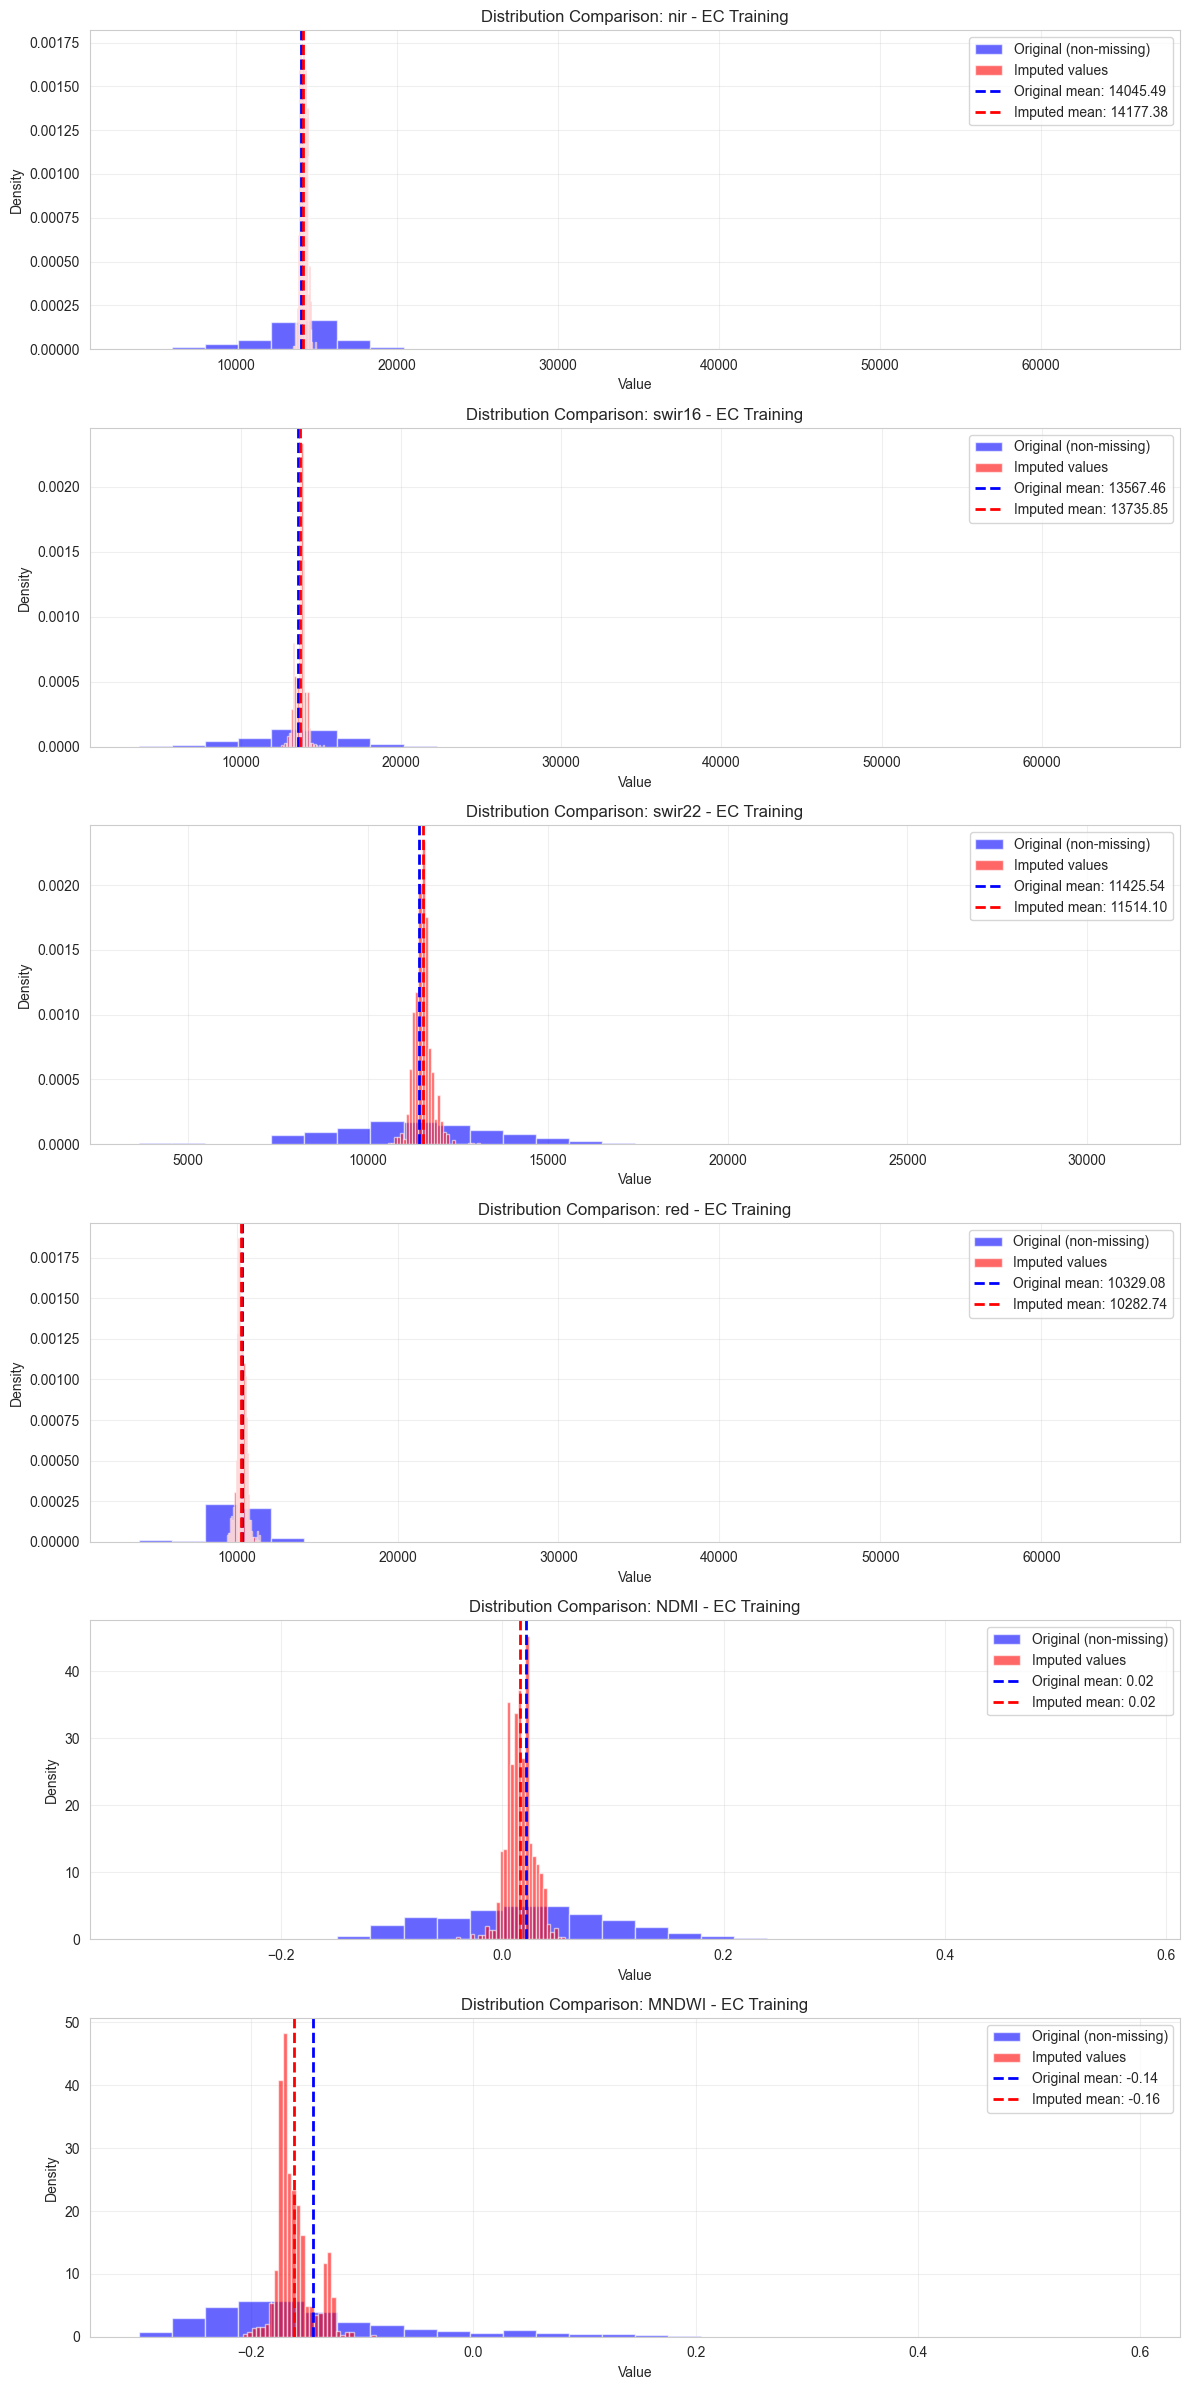


Validation: EC Validation

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14462.9558, Std: 2292.4889
    Min: 6281.0000, Max: 21308.0000
  Imputed values statistics:
    Mean: 15802.5289, Std: 977.6329
    Min: 13239.2500, Max: 17299.0500
  After imputation (all values):
    Mean: 14590.2152, Std: 2235.0007

swir16:
  Original (non-missing) statistics:
    Mean: 12332.0110, Std: 2031.5636
    Min: 5173.5000, Max: 18512.5000
  Imputed values statistics:
    Mean: 12506.7421, Std: 288.7278
    Min: 11824.4000, Max: 12970.6000
  After imputation (all values):
    Mean: 12348.6105, Std: 1934.7791

swir22:
  Original (non-missing) statistics:
    Mean: 10297.0884, Std: 1702.4975
    Min: 4286.5000, Max: 16452.0000
  Imputed values statistics:
    Mean: 10045.3632, Std: 227.6377
    Min: 9585.1000, Max: 10481.3500
  After imputation (all values):
    Mean: 10273.1745, Std: 1622.3190

red:
  Original (non-missing) statistics:
    Mean: 97

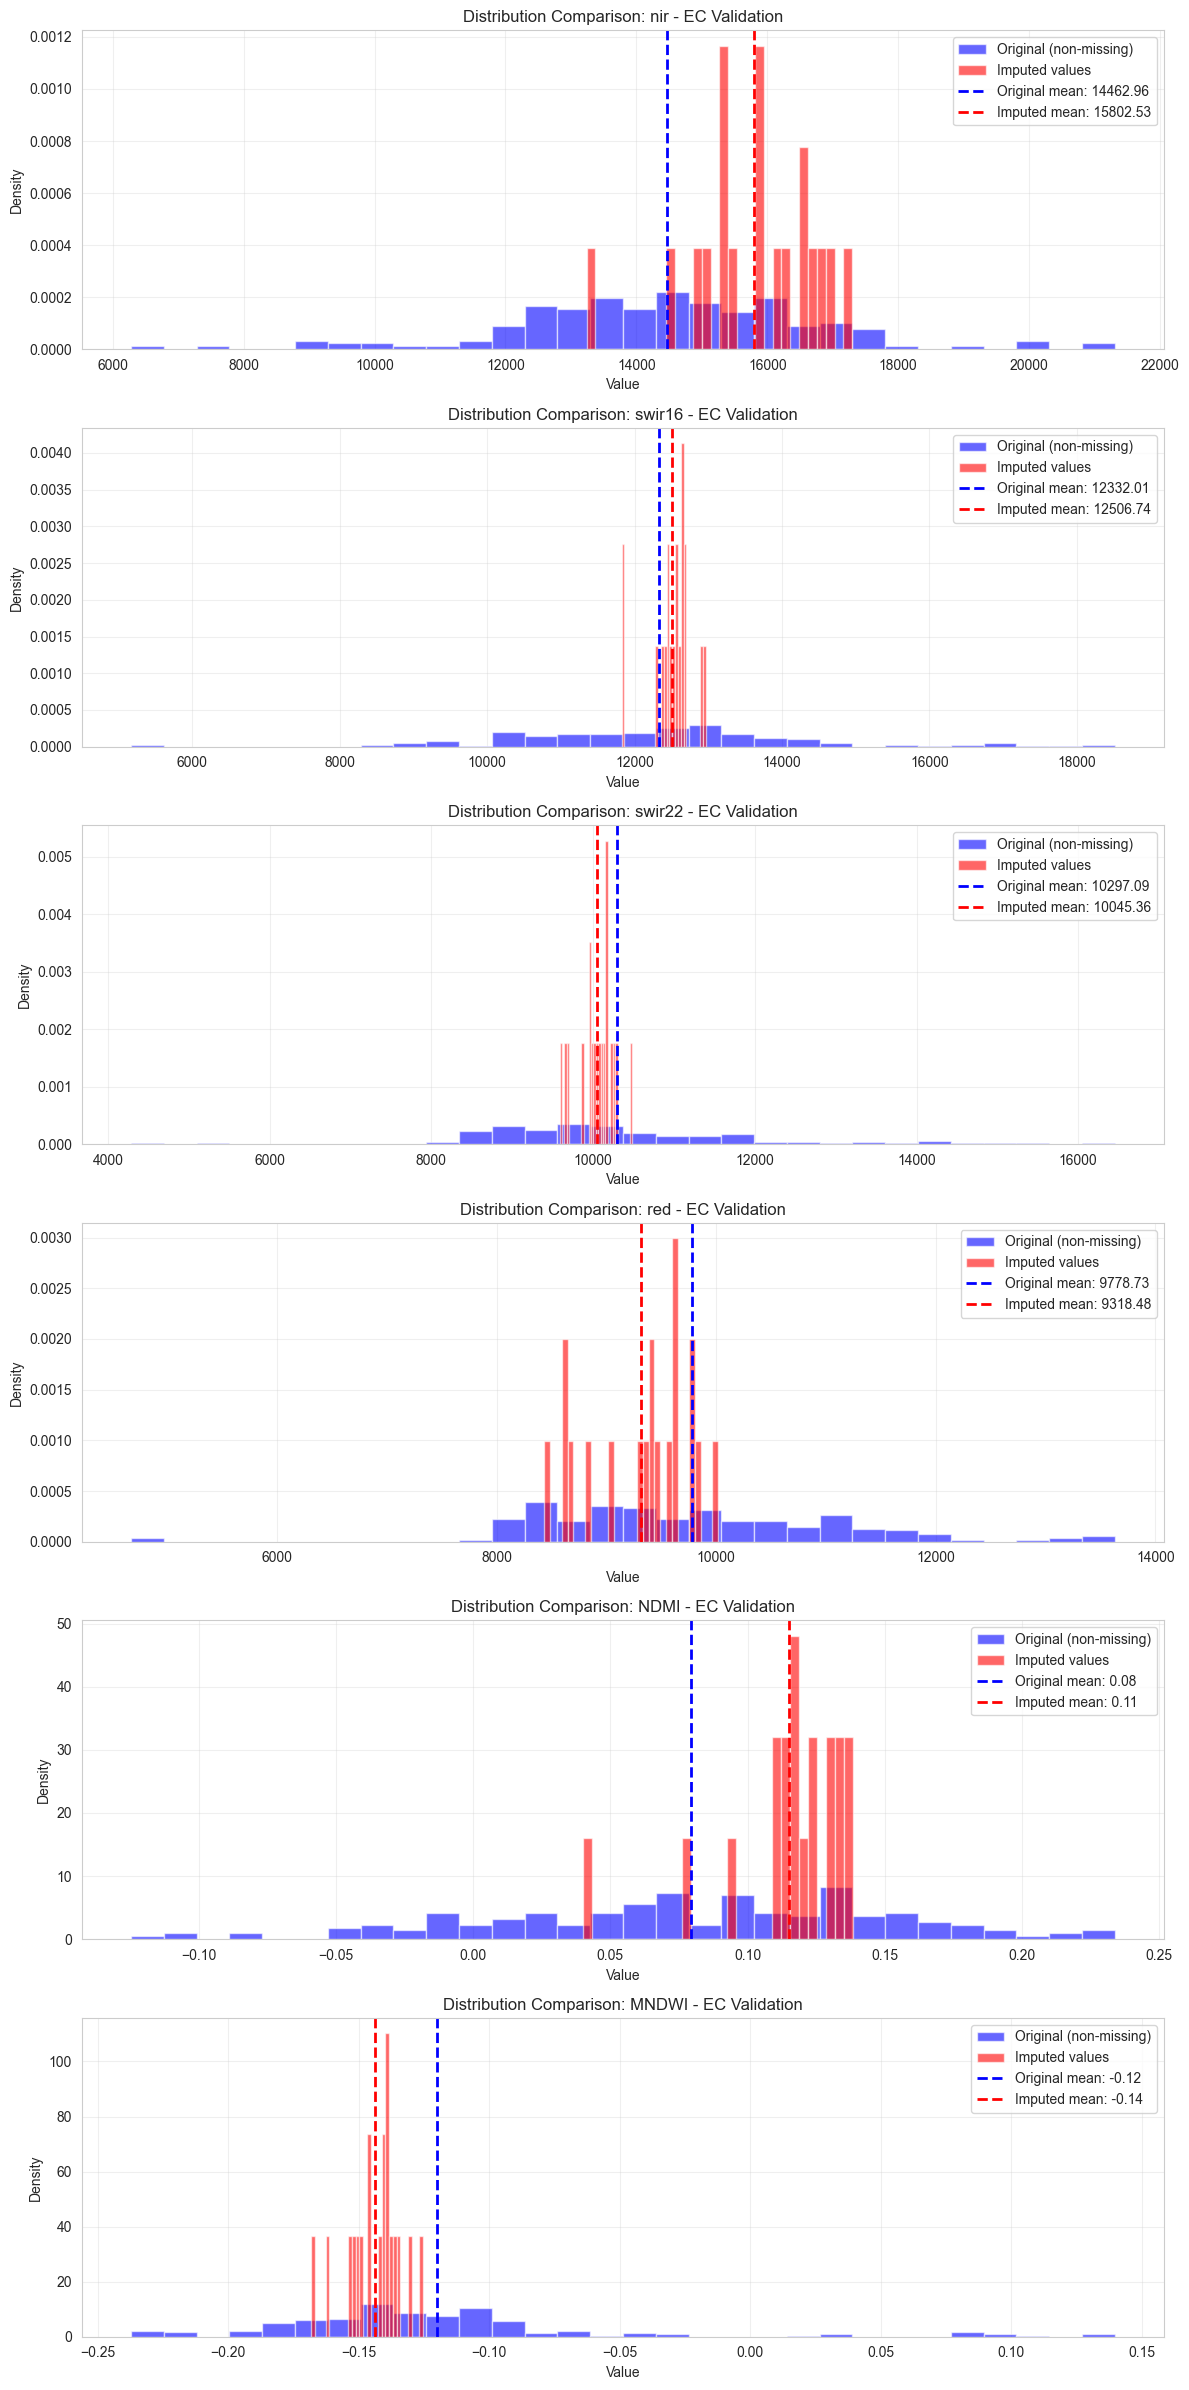


Validation: TA Training

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14045.4854, Std: 2953.2236
    Min: 3992.0000, Max: 65535.0000
  Imputed values statistics:
    Mean: 14177.3816, Std: 215.4436
    Min: 13557.5000, Max: 14961.9500
  After imputation (all values):
    Mean: 14060.8419, Std: 2777.2600

swir16:
  Original (non-missing) statistics:
    Mean: 13567.4593, Std: 3348.5177
    Min: 3672.5000, Max: 65535.0000
  Imputed values statistics:
    Mean: 13735.8478, Std: 290.6577
    Min: 12544.5500, Max: 15218.5500
  After imputation (all values):
    Mean: 13587.0646, Std: 3149.5571

swir22:
  Original (non-missing) statistics:
    Mean: 11425.5384, Std: 2548.1935
    Min: 3634.0000, Max: 31202.5000
  Imputed values statistics:
    Mean: 11514.1047, Std: 247.0174
    Min: 10543.6000, Max: 13116.4000
  After imputation (all values):
    Mean: 11435.8500, Std: 2396.8956

red:
  Original (non-missing) statistics:
    Mean: 103

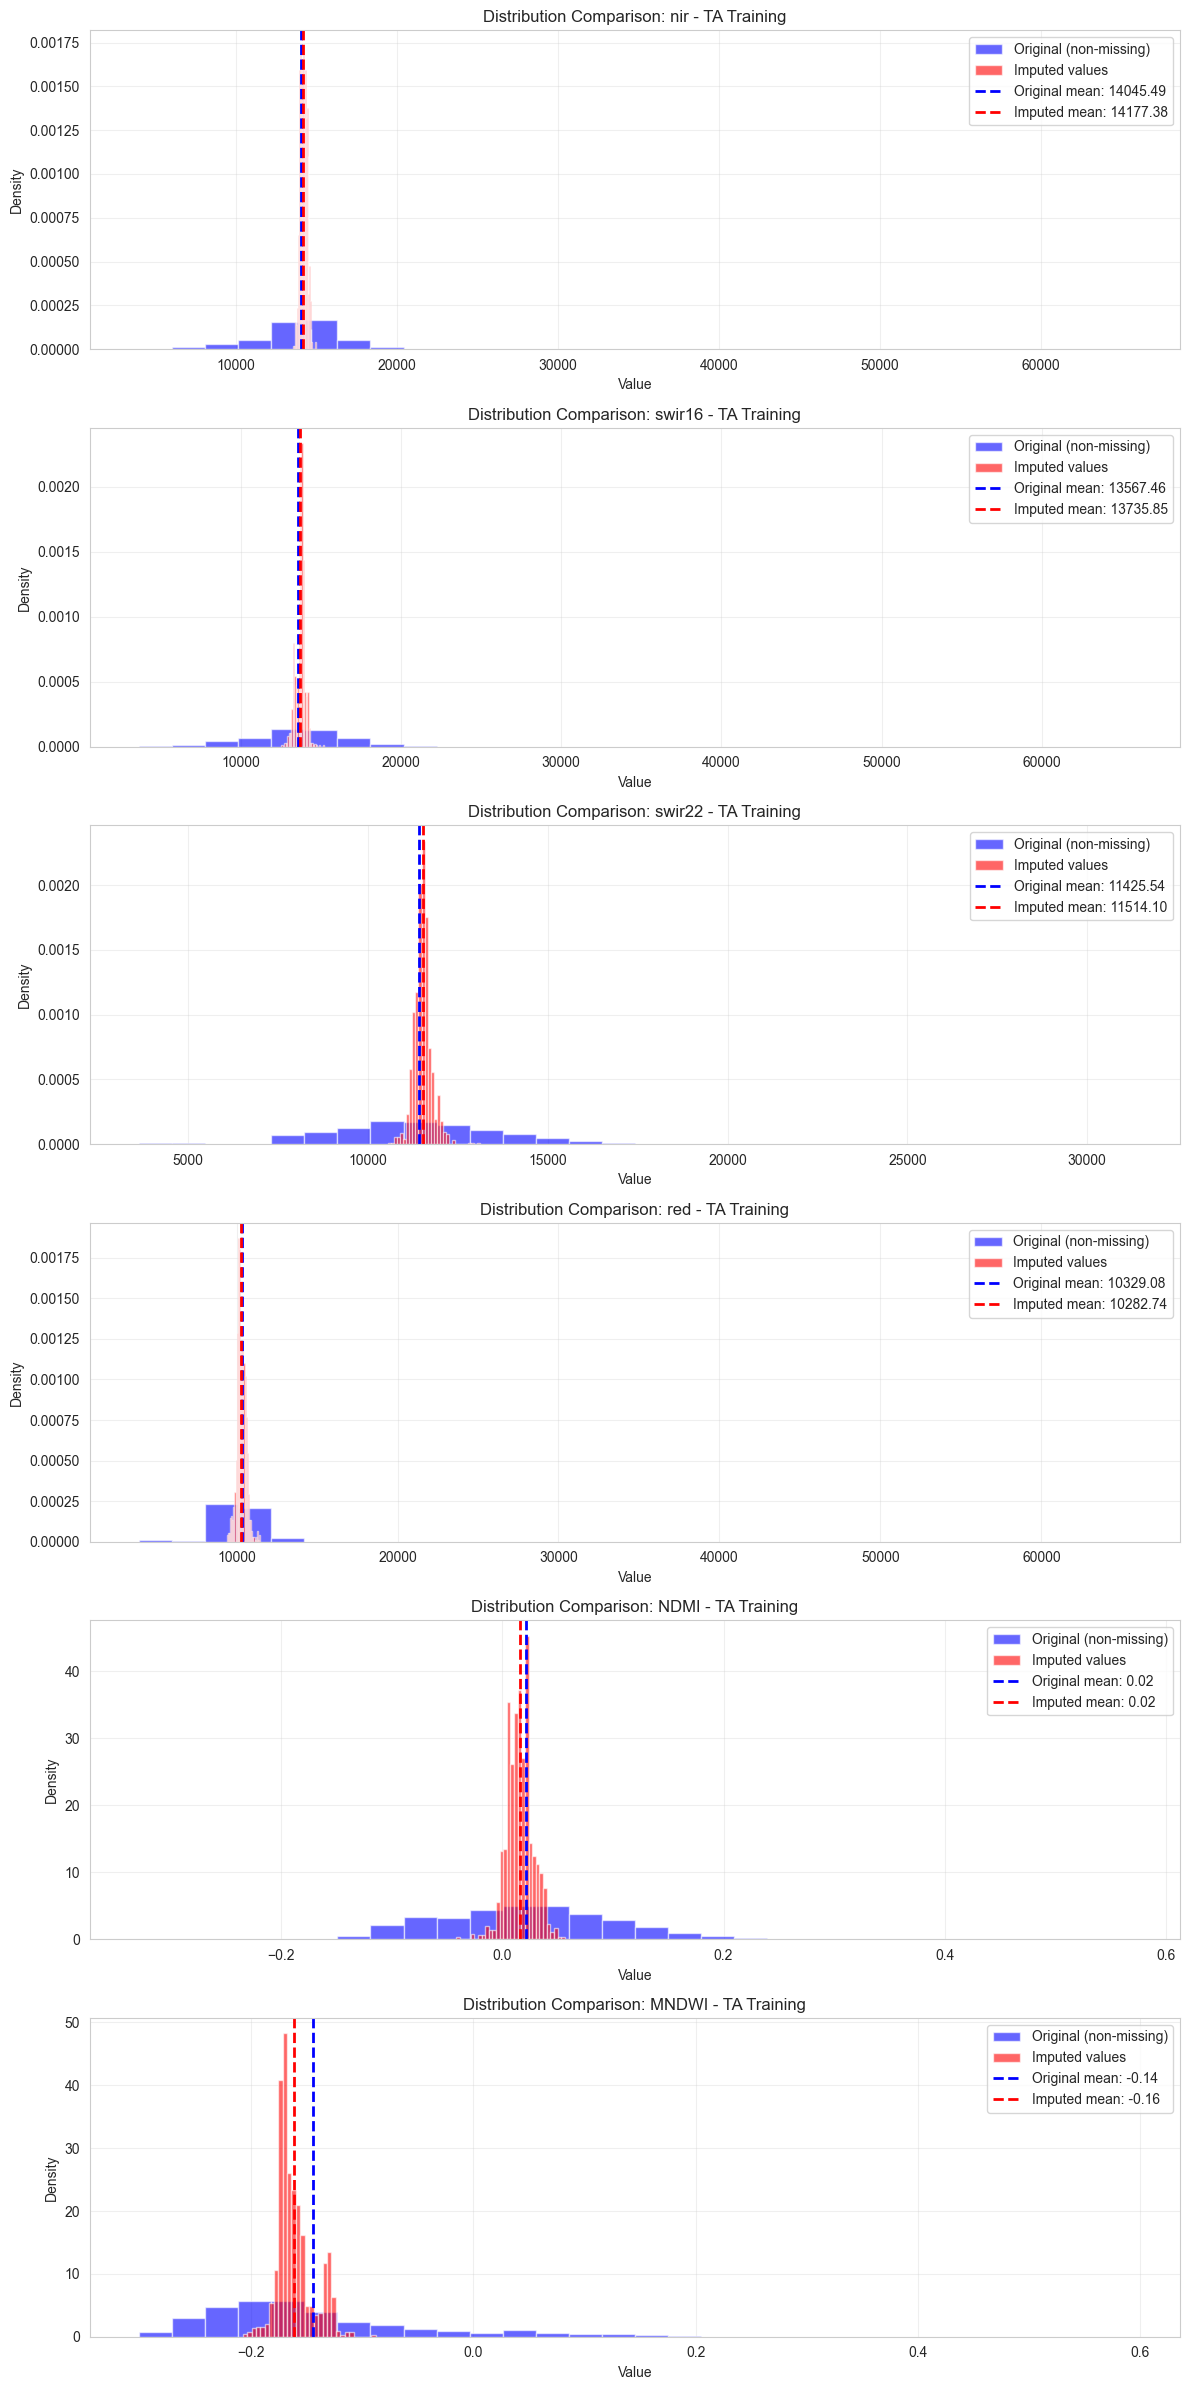


Validation: TA Validation

Validating 6 features that had missing values:


nir:
  Original (non-missing) statistics:
    Mean: 14462.9558, Std: 2292.4889
    Min: 6281.0000, Max: 21308.0000
  Imputed values statistics:
    Mean: 15802.5289, Std: 977.6329
    Min: 13239.2500, Max: 17299.0500
  After imputation (all values):
    Mean: 14590.2152, Std: 2235.0007

swir16:
  Original (non-missing) statistics:
    Mean: 12332.0110, Std: 2031.5636
    Min: 5173.5000, Max: 18512.5000
  Imputed values statistics:
    Mean: 12506.7421, Std: 288.7278
    Min: 11824.4000, Max: 12970.6000
  After imputation (all values):
    Mean: 12348.6105, Std: 1934.7791

swir22:
  Original (non-missing) statistics:
    Mean: 10297.0884, Std: 1702.4975
    Min: 4286.5000, Max: 16452.0000
  Imputed values statistics:
    Mean: 10045.3632, Std: 227.6377
    Min: 9585.1000, Max: 10481.3500
  After imputation (all values):
    Mean: 10273.1745, Std: 1622.3190

red:
  Original (non-missing) statistics:
    Mean: 97

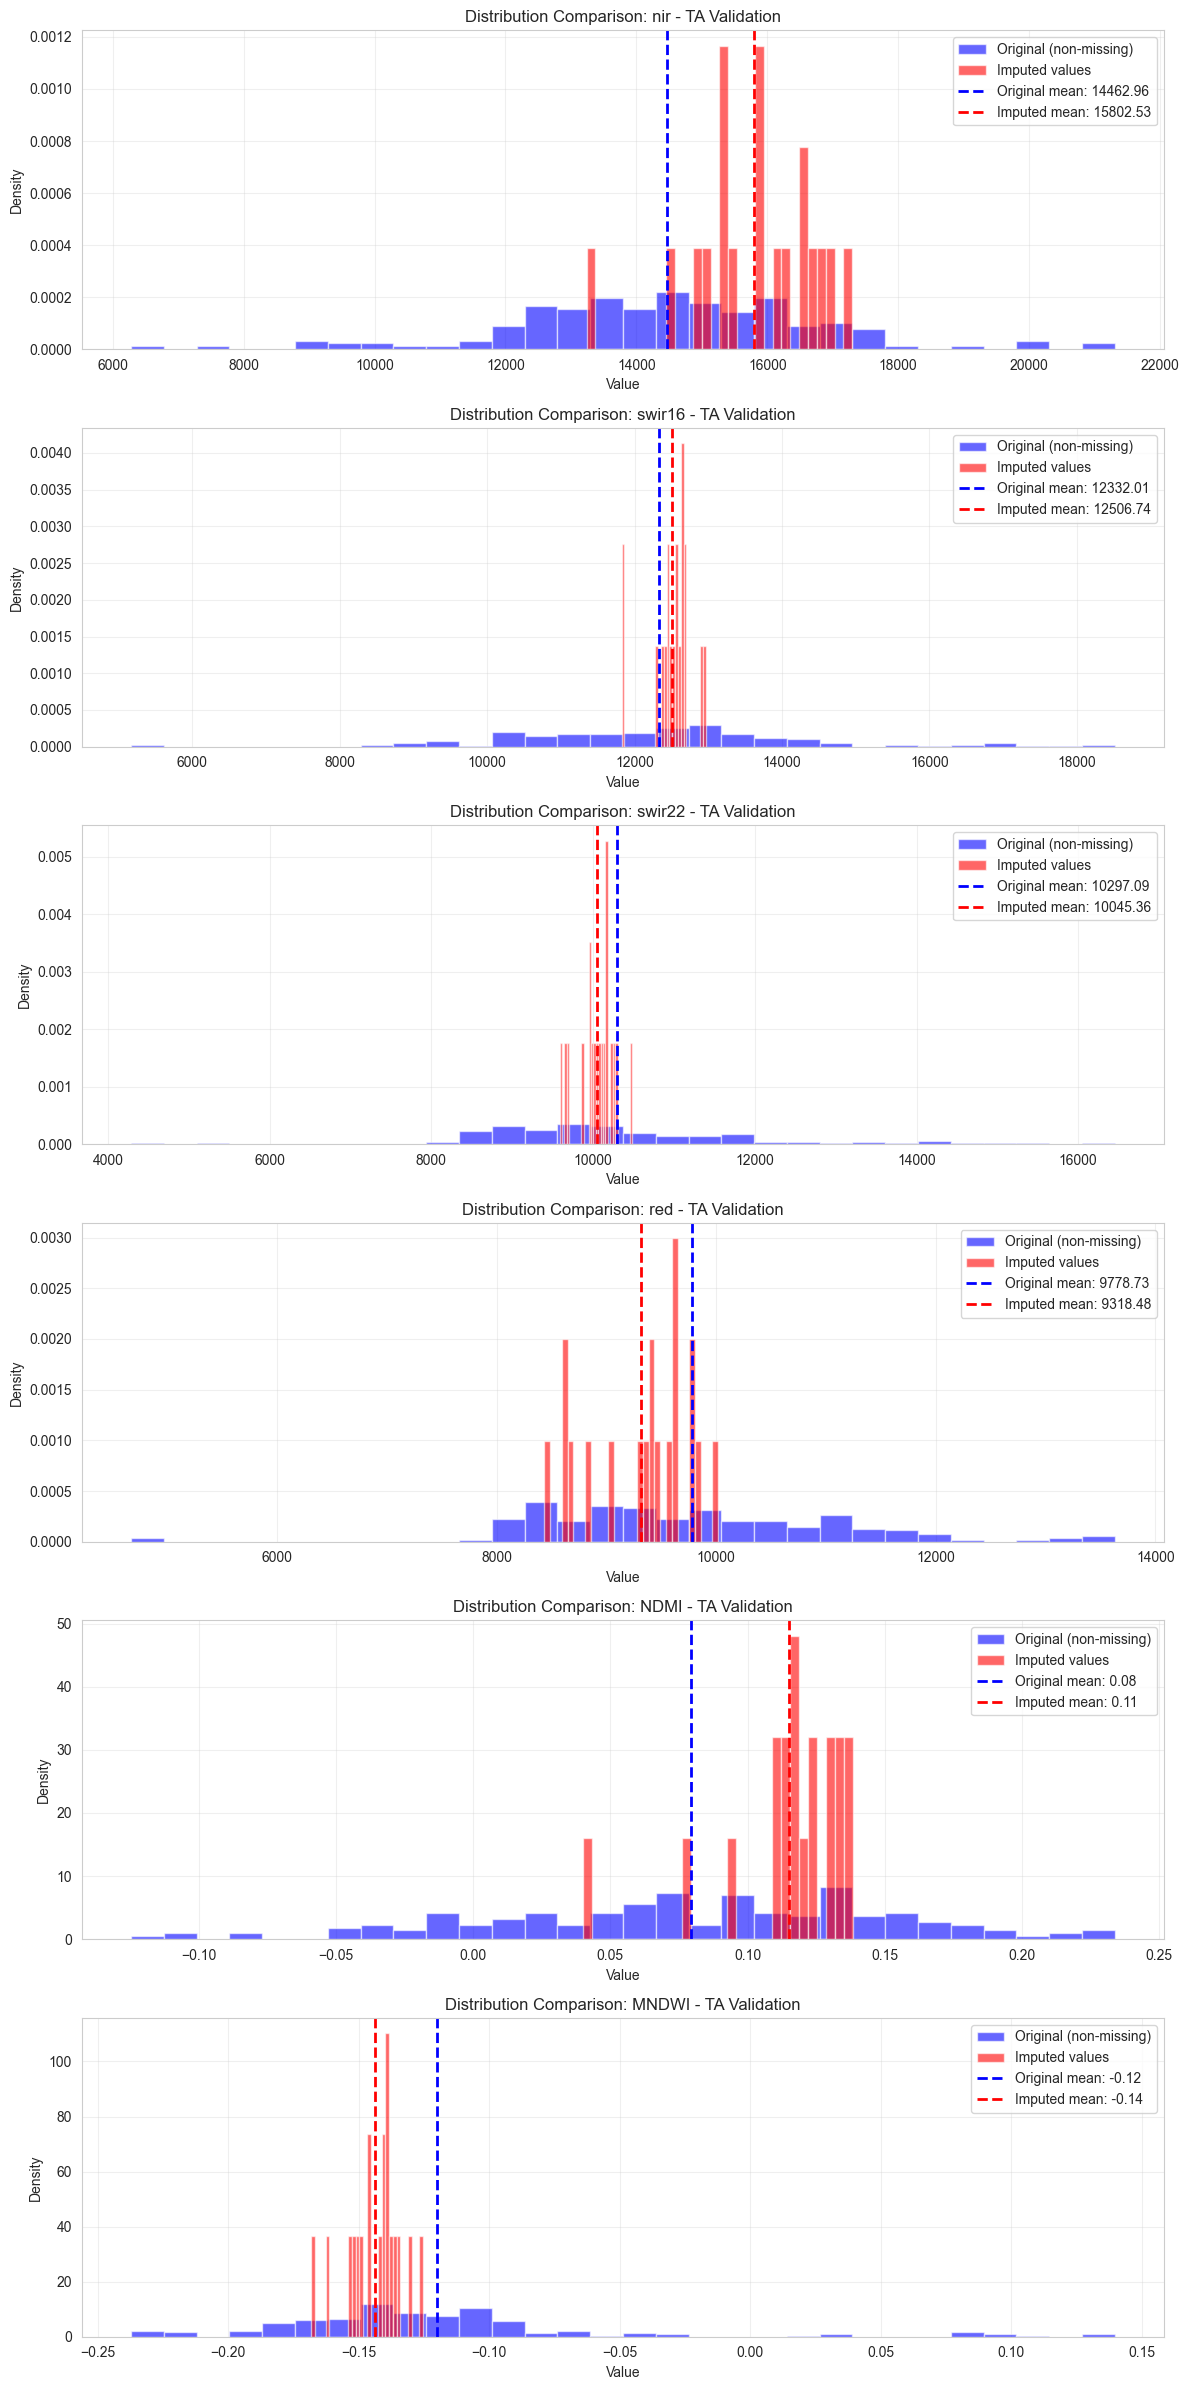

In [12]:
def validate_imputation(original_df, imputed_df, dataset_name):
    """
    Validate imputation by comparing distributions
    """
    print(f"\n{'='*80}")
    print(f"Validation: {dataset_name}")
    print(f"{'='*80}")
    
    # Find features that had missing values
    metadata_cols = ['latitude', 'longitude', 'sample_date']
    feature_cols = [col for col in original_df.columns if col not in metadata_cols]
    
    features_with_missing = original_df[feature_cols].columns[original_df[feature_cols].isnull().any()].tolist()
    
    if not features_with_missing:
        print("No features had missing values - no validation needed")
        return
    
    print(f"\nValidating {len(features_with_missing)} features that had missing values:\n")
    
    # For each feature with missing values, compare statistics
    for feature in features_with_missing:
        original_values = original_df[feature].dropna()
        imputed_values = imputed_df[feature][original_df[feature].isnull()]
        all_imputed_values = imputed_df[feature]
        
        print(f"\n{feature}:")
        print(f"  Original (non-missing) statistics:")
        print(f"    Mean: {original_values.mean():.4f}, Std: {original_values.std():.4f}")
        print(f"    Min: {original_values.min():.4f}, Max: {original_values.max():.4f}")
        print(f"  Imputed values statistics:")
        print(f"    Mean: {imputed_values.mean():.4f}, Std: {imputed_values.std():.4f}")
        print(f"    Min: {imputed_values.min():.4f}, Max: {imputed_values.max():.4f}")
        print(f"  After imputation (all values):")
        print(f"    Mean: {all_imputed_values.mean():.4f}, Std: {all_imputed_values.std():.4f}")
    
    # Visualize distributions for features with missing values
    num_features = len(features_with_missing)
    if num_features > 0:
        fig, axes = plt.subplots(num_features, 1, figsize=(12, 4*num_features))
        if num_features == 1:
            axes = [axes]
        
        for idx, feature in enumerate(features_with_missing):
            original_values = original_df[feature].dropna()
            imputed_values = imputed_df[feature][original_df[feature].isnull()]
            
            axes[idx].hist(original_values, bins=30, alpha=0.6, label='Original (non-missing)', 
                          color='blue', density=True)
            axes[idx].hist(imputed_values, bins=30, alpha=0.6, label='Imputed values', 
                          color='red', density=True)
            axes[idx].axvline(original_values.mean(), color='blue', linestyle='--', 
                            linewidth=2, label=f'Original mean: {original_values.mean():.2f}')
            axes[idx].axvline(imputed_values.mean(), color='red', linestyle='--', 
                            linewidth=2, label=f'Imputed mean: {imputed_values.mean():.2f}')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Density')
            axes[idx].set_title(f'Distribution Comparison: {feature} - {dataset_name}')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Validate each dataset
for name in datasets.keys():
    validate_imputation(datasets[name], imputed_datasets[name], name)

## 8. Save Imputed Datasets

Save the imputed datasets to new CSV files.

In [13]:
# Save imputed datasets
output_path = Path('../New Datasets/Combined/Final Datasets')

file_mapping = {
    'DRP Training': 'drp_training.csv',
    'DRP Validation': 'drp_validation.csv',
    'EC Training': 'ec_training.csv',
    'EC Validation': 'ec_validation.csv',
    'TA Training': 'ta_training.csv',
    'TA Validation': 'ta_validation.csv'
}

print("="*80)
print("SAVING IMPUTED DATASETS")
print("="*80)

for name, filename in file_mapping.items():
    output_file = output_path / filename
    imputed_datasets[name].to_csv(output_file, index=False)
    print(f"✓ Saved: {filename}")
    print(f"  Shape: {imputed_datasets[name].shape}")
    print(f"  Missing values: {imputed_datasets[name].isnull().sum().sum()}")
    print()

print("="*80)
print("ALL IMPUTED DATASETS SAVED SUCCESSFULLY")
print("="*80)
print(f"\nLocation: {output_path.absolute()}")

SAVING IMPUTED DATASETS
✓ Saved: drp_training.csv
  Shape: (9319, 25)
  Missing values: 0

✓ Saved: drp_validation.csv
  Shape: (200, 25)
  Missing values: 0

✓ Saved: ec_training.csv
  Shape: (9319, 25)
  Missing values: 0

✓ Saved: ec_validation.csv
  Shape: (200, 25)
  Missing values: 0

✓ Saved: ta_training.csv
  Shape: (9319, 25)
  Missing values: 0

✓ Saved: ta_validation.csv
  Shape: (200, 25)
  Missing values: 0

ALL IMPUTED DATASETS SAVED SUCCESSFULLY

Location: /Users/ethan/Documents/EY Challenge/Water-Quality-Prediction/Our Notebooks/../New Datasets/Combined/Final Datasets


## Summary

This notebook performed comprehensive missing data analysis and imputation:

### Analysis Steps:
1. **Missing per Feature**: Identified which features have missing values and their percentages
2. **Missing per Row**: Analyzed distribution of missingness across rows
3. **Missingness Correlations**: Examined patterns in how features tend to be missing together
4. **Cross-Dataset Comparison**: Compared missing data patterns across all 6 datasets

### Imputation Method:
- **IterativeImputer (MICE)** with RandomForest estimator
- Models each feature with missing values as a function of other features
- Captures non-linear relationships between variables
- More sophisticated than simple mean/median imputation

### Validation:
- Compared distributions of imputed values vs. original values
- Ensured imputed values are statistically reasonable
- All missing values successfully filled

### Output:
- Imputed datasets saved back to the original file locations
- All datasets now have complete data with no missing values

## 4. Cross-Dataset Comparison


CROSS-DATASET MISSING DATA SUMMARY


       Dataset  Rows  Columns  Total Cells  Missing Cells  Missing %  Features w/ Missing  Rows w/ Missing  Rows w/ Missing %
  DRP Training  9319       25       232975           6510   2.794291                    6             1085           11.64288
DRP Validation   200       25         5000            114   2.280000                    6               19            9.50000
   EC Training  9319       25       232975           6510   2.794291                    6             1085           11.64288
 EC Validation   200       25         5000            114   2.280000                    6               19            9.50000
   TA Training  9319       25       232975           6510   2.794291                    6             1085           11.64288
 TA Validation   200       25         5000            114   2.280000                    6               19            9.50000


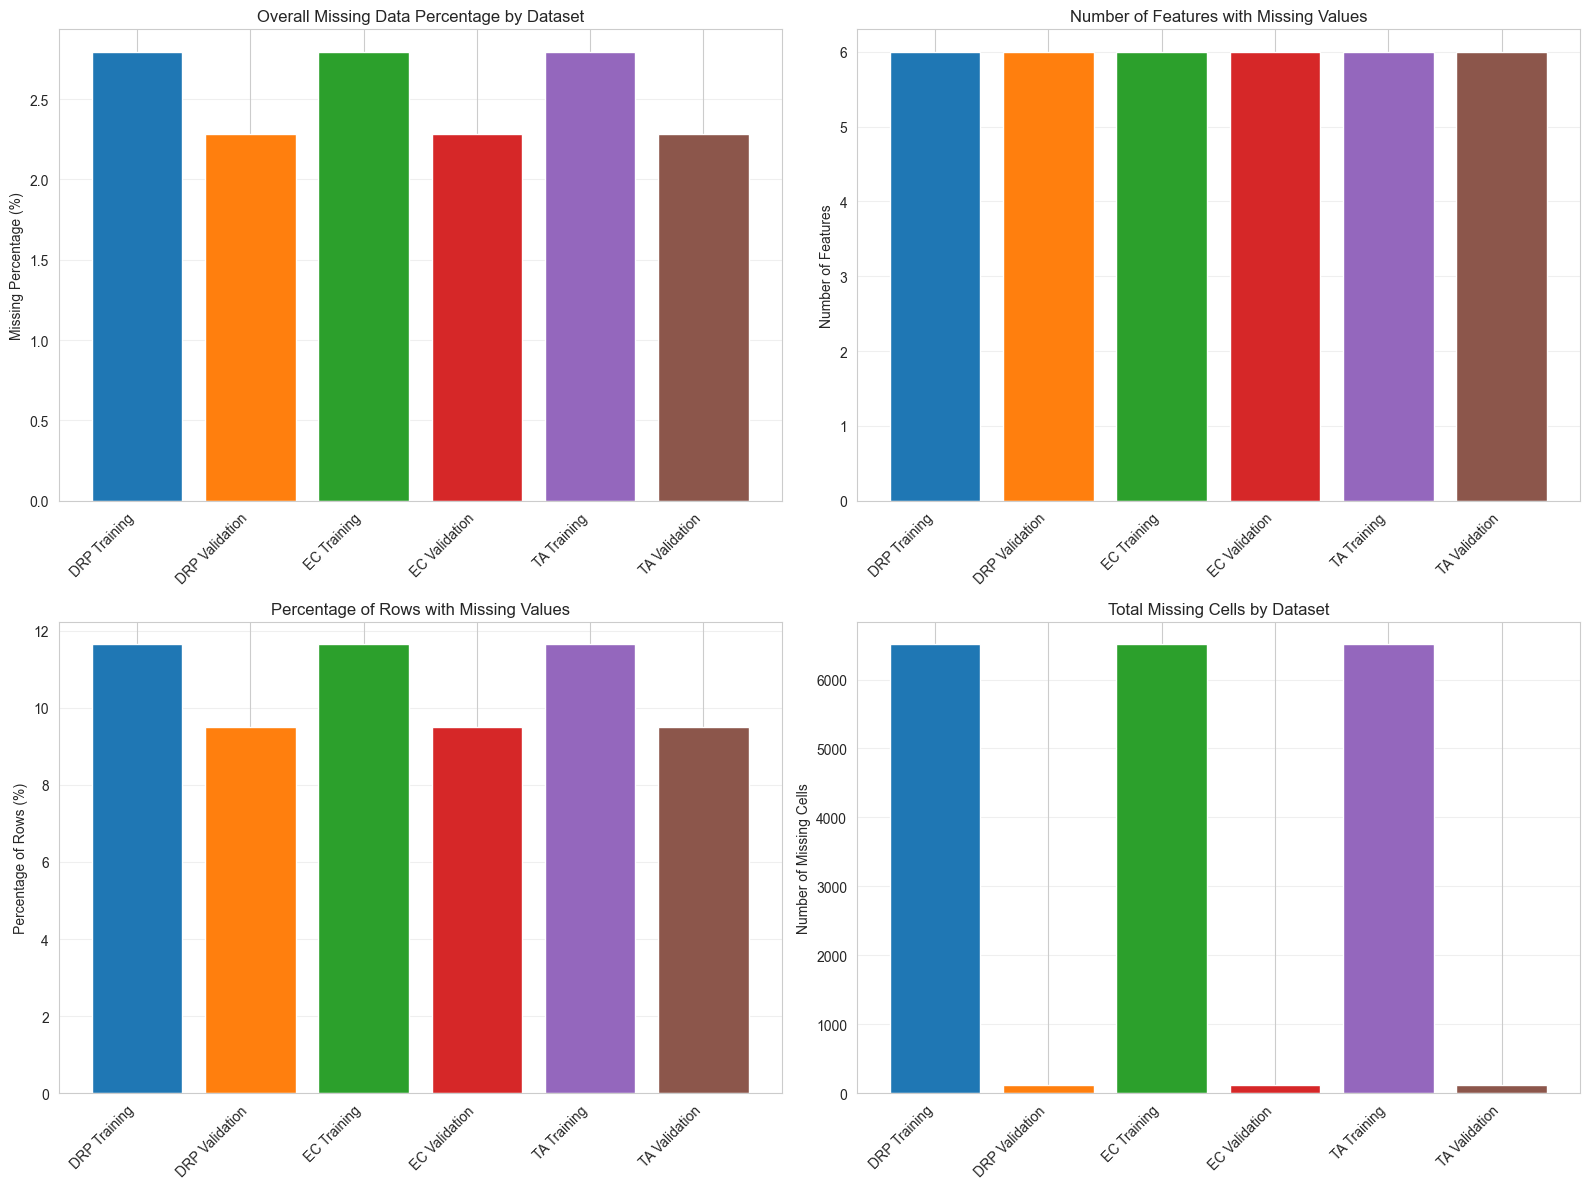

In [14]:
# Compare missing data across all datasets
print("\n" + "="*80)
print("CROSS-DATASET MISSING DATA SUMMARY")
print("="*80)

summary_data = []
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    missing_pct = (missing_cells / total_cells) * 100
    
    features_with_missing = (df.isnull().sum() > 0).sum()
    rows_with_missing = (df.isnull().sum(axis=1) > 0).sum()
    
    summary_data.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Total Cells': total_cells,
        'Missing Cells': missing_cells,
        'Missing %': missing_pct,
        'Features w/ Missing': features_with_missing,
        'Rows w/ Missing': rows_with_missing,
        'Rows w/ Missing %': (rows_with_missing / df.shape[0]) * 100
    })

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall missing percentage
axes[0, 0].bar(range(len(summary_df)), summary_df['Missing %'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[0, 0].set_xticks(range(len(summary_df)))
axes[0, 0].set_xticklabels(summary_df['Dataset'], rotation=45, ha='right')
axes[0, 0].set_ylabel('Missing Percentage (%)')
axes[0, 0].set_title('Overall Missing Data Percentage by Dataset')
axes[0, 0].grid(axis='y', alpha=0.3)

# Features with missing values
axes[0, 1].bar(range(len(summary_df)), summary_df['Features w/ Missing'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[0, 1].set_xticks(range(len(summary_df)))
axes[0, 1].set_xticklabels(summary_df['Dataset'], rotation=45, ha='right')
axes[0, 1].set_ylabel('Number of Features')
axes[0, 1].set_title('Number of Features with Missing Values')
axes[0, 1].grid(axis='y', alpha=0.3)

# Percentage of rows with missing values
axes[1, 0].bar(range(len(summary_df)), summary_df['Rows w/ Missing %'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[1, 0].set_xticks(range(len(summary_df)))
axes[1, 0].set_xticklabels(summary_df['Dataset'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Percentage of Rows (%)')
axes[1, 0].set_title('Percentage of Rows with Missing Values')
axes[1, 0].grid(axis='y', alpha=0.3)

# Missing cells count
axes[1, 1].bar(range(len(summary_df)), summary_df['Missing Cells'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[1, 1].set_xticks(range(len(summary_df)))
axes[1, 1].set_xticklabels(summary_df['Dataset'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Number of Missing Cells')
axes[1, 1].set_title('Total Missing Cells by Dataset')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Missing Data Patterns Summary

In [15]:
# Identify which features have missing values across all datasets
print("\n" + "="*80)
print("FEATURES WITH MISSING VALUES ACROSS ALL DATASETS")
print("="*80)

all_features = set()
for df in datasets.values():
    all_features.update(df.columns)

feature_missing_summary = {}
for feature in sorted(all_features):
    missing_in_datasets = []
    for name, df in datasets.items():
        if feature in df.columns:
            missing_pct = (df[feature].isnull().sum() / len(df)) * 100
            if missing_pct > 0:
                missing_in_datasets.append((name, missing_pct))
    
    if missing_in_datasets:
        feature_missing_summary[feature] = missing_in_datasets

if feature_missing_summary:
    for feature, dataset_info in sorted(feature_missing_summary.items()):
        print(f"\n{feature}:")
        for dataset_name, pct in dataset_info:
            print(f"  - {dataset_name}: {pct:.2f}%")
else:
    print("\n✓ No features have missing values across any datasets!")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


FEATURES WITH MISSING VALUES ACROSS ALL DATASETS

MNDWI:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

NDMI:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

nir:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

red:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

swir16:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

swir22:
  - DRP Training: 11.64%
  - DRP Validation: 9.50%
  - EC Training: 11.64%
  - EC Validation: 9.50%
  - TA Training: 11.64%
  - TA Validation: 9.50%

ANALYSIS C